# $^{6}\mathrm{Li}$ estimations for the TRSA experiment at DHIPS

* this notebook estimate the self absorption at given temperatures and 
* the thicknesses of the absorption and scattering targets

## Initialzation

In [1]:
import warnings

import os
import sys
import numpy as np
from uncertainties import ufloat
sys.path.append("/home/kprifti/DHIPS2024/TRSA_on_Al27/analysis/ries")
import ries
from scipy.constants import physical_constants
from ries.constituents.element import Element, natural_elements
from ries.constituents.isotope import Isotope
from ries.constituents.state import GroundState, State
#from ries.resonance.voigt import Voigt
from ries.resonance.debye_model import effective_temperature_debye_approximation
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import physical_constants
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.stats import norm
from time import time

import arviz as az
import pandas as pd
from scipy.stats import truncnorm

import pymc as pm
import pytensor.tensor as pt

In [2]:
from scipy.optimize import newton
from scipy.stats import cauchy, norm

from ries.resonance.maxwell_boltzmann import MaxwellBoltzmann
from ries.resonance.resonance import Resonance


class PseudoVoigtDistribution:
    """Class for a pseudo-Voigt distribution

    Approximates a Voigt distribution by a linear combination of a normal distribution and a
    Cauchy distribution instead of a convolution.
    For the mixing constant, an expression by Thompson *et al.* :cite:`Thompson1987` is used.

    Attributes:

    - `resonance_energy`, float, resonance energy, i.e. location of the centroid in MeV.
    - `maxwell_boltzmann`, `MaxwellBoltzmann` object, used to calculate the doppler width.
    - `Gamma_L_*`, `Gamma_G_*`, float, parameters used in the approximation of Thompson et al. in units of different powers of MeV.
    - `sigma`, float, standard deviation of the Doppler-broadened normal distribution in MeV.
    - `Gamma`, float, full width at half maximum (FWHM) of the normal distribution in MeV, used in the approximation of Thompson et al..
    - `gamma`, float, scale parameter of the Cauchy distribution.
    - `eta`, float, mixing parameter that controls the relative contributions of the normal- and the Cauchy distribution to the linear combination.
    """

    def __init__(self, resonance_energy, width, amu, effective_temperature):
        """Initialization

        Parameters:

        - `resonance_energy`, float, resonance energy, i.e. location of the centroid in MeV.
        - `width`, float, the width of the excited state in MeV.
        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.
        """
        self.resonance_energy = resonance_energy
        self.maxwell_boltzmann = MaxwellBoltzmann(amu, effective_temperature)

        self.Gamma_L = width
        self.Gamma_L_squared = self.Gamma_L * self.Gamma_L
        self.Gamma_L_cubed = self.Gamma_L_squared * self.Gamma_L
        self.Gamma_L_squared_squared = self.Gamma_L_squared * self.Gamma_L_squared
        self.doppler_width = self.maxwell_boltzmann.get_doppler_width(
            self.resonance_energy
        )
        self.sigma = self.doppler_width / np.sqrt(2.0)
        self.Gamma_G = 2.0 * np.sqrt(np.log(2.0)) * self.doppler_width
        self.Gamma_G_squared = self.Gamma_G * self.Gamma_G
        self.Gamma_G_squared_squared = self.Gamma_G_squared * self.Gamma_G_squared

        self.Gamma = self.get_Gamma()
        self.eta = self.get_eta()
        self.gamma_G = self.Gamma / (2.0 * np.sqrt(np.log(2.0)))
        self.gamma_L = 0.5 * self.Gamma

        self.gamma = 0.5 * width

    def pseudo_voigt_expression(self, x, method):
        """Evaluate linear combination of normal- and Cauchy distribution

        To avoid repetitive code, this function replaces 'pdf', 'cdf', and 'ppf' in the general
        linear-combination expression.

        Parameters:

        - `x`, float or array_like, meaning depends on the `method` parameter, but it is most probably an energy in MeV (`method == 'pdf'` or `method == 'cdf'`)  or a quantile (`method == ppf`).
        - `method`, str, method of the distributions that should be called, for example 'pdf', 'cdf', or 'ppf'.

        Returns:

        - float or array_like, meaning depends on the `method` parameter, but it is most probably an energy in MeV (`method == 'ppf'`), a probability (`method == pdf`), or a quantile (`method == cdf`).
        """
        return eval(
            """(1.0 - self.eta) * norm.{}(
            x, loc=self.resonance_energy, scale=self.gamma_G / np.sqrt(2.0)
        ) + self.eta * cauchy.{}(
            x, loc=self.resonance_energy, scale=0.5 * self.gamma_L
        )""".format(
                method, method
            )
        )

    def cdf(self, E):
        """CDF of the pseudo-Voigt distribution

        Parameters:

        - `E`, float or array_like, energy in MeV.

        Returns:

        float or array_like, CDF
        """
        return self.pseudo_voigt_expression(E, "cdf")

    def pdf(self, E):
        """PDF of the pseudo-Voigt distribution

        Parameters:

        - `E`, float or array_like, energy in MeV.

        Returns:

        float or array_like, PDF
        """
        return self.pseudo_voigt_expression(E, "pdf")

    def ppf(self, quantile):
        """PPF of the pseudo-Voigt distribution

        This function tries to invert the pseudo-Voigt CDF numerically first.
        If the root-finding algorithm does not converge for any of the given quantiles, the
        RuntimeError issued by the algorithm is caught and a fallback approximation is used which
        is based on a linear combination of PPFs.

        Parameters:

        - `quantile`, float or array_like, quantile.

        Returns:

        float or array_like, PPF
        """

        try:
            # scipy.optimize.newton returns different output depending on whether quantile is a
            # scalar or an array.
            # For a scalar, the root is `newton_result[0]` and the flag that indicates whether
            # the algorithm converged is `newton_result[1]`.converged`.
            # In the case of an array, it is `newton_result[0]` and `newton_result[1]`.
            newton_result = newton(
                lambda E: self.pseudo_voigt_expression(E, "cdf") - quantile,
                # Use resonance energy as start value.
                # There are closer guesses for an arbitrary q, but starting at the resonance
                # energy ensures that the algorithm does not have rounding errors from the start
                # which might cause it to go in the wrong direction.
                self.resonance_energy
                if isinstance(quantile, (float, int))
                else self.resonance_energy * np.ones(len(quantile)),
                fprime=lambda E: self.pseudo_voigt_expression(E, "pdf"),
                full_output=True,
            )
            if isinstance(quantile, (int, float)):
                if newton_result[1].converged:
                    return newton_result[0]
            elif False not in newton_result[1]:
                return newton_result[0]

        except RuntimeError:
            warnings.warn(
                "Calculation of pseudo-Voigt PPF by numerical inversion of the CDF failed for at least one value. Using approximation instead.",
                UserWarning,
            )
            return self.pseudo_voigt_expression(quantile, "ppf")

    def get_Gamma(self):
        """Calculate Gamma parameter

        This parameter is used internally in the approximation of Thompson et al..
        """
        return (
            self.Gamma_G_squared_squared * self.Gamma_G
            + 2.69269 * self.Gamma_G_squared_squared * self.Gamma_L
            + 2.42843 * self.Gamma_G_squared * self.Gamma_G * self.Gamma_L_squared
            + 4.47163 * self.Gamma_G_squared * self.Gamma_L_cubed
            + 0.07842 * self.Gamma_G * self.Gamma_L_squared_squared
            + self.Gamma_L_squared_squared * self.Gamma_L
        ) ** 0.2

    def get_eta(self):
        """Calculate mixing parameter"""
        inverse_Gamma = 1.0 / self.Gamma
        inverse_Gamma_squared = inverse_Gamma * inverse_Gamma
        return (
            1.36603 * self.Gamma_L * inverse_Gamma
            - 0.47719 * self.Gamma_L_squared * inverse_Gamma_squared
            + 0.11116 * self.Gamma_L_cubed * inverse_Gamma_squared * inverse_Gamma
        )


class PseudoVoigt(Resonance):
    r"""Approximation for a Doppler-broadened Breit-Wigner cross section (pseudo-Voigt profile)

    See `ries.resonance.resonance.Resonance`.
    """

    def __init__(
        self,
        initial_state,
        intermediate_state,
        amu,
        effective_temperature,
        final_state=None,
    ):
        r"""Initialization

        Parameters:

        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.

        See also `ries.resonance.resonance.Resonance`.
        """
        Resonance.__init__(self, initial_state, intermediate_state, final_state)

        self.probability_distribution = PseudoVoigtDistribution(
            self.resonance_energy,
            self.intermediate_state.width,
            amu,
            effective_temperature,
        )
        self.probability_distribution_parameters = ()


In [3]:
from scipy.special import voigt_profile

class SemiPseudoVoigtDistribution(PseudoVoigtDistribution):
    """Class for a Voigt distribution, using pseudo-Voigt expressions for CDF and PPF

    The `pdf()` method calls `scipy.special.voigt_profile`, while the CDF and the PPF are approximated
    by a pseudo-Voigt distribution (see `ries.resonance.pseudo_voigt`).

    See also `ries.resonance.pseudo_voigt.PseudoVoigtDistribution`.
    """

    def pdf(self, E):
        """PDF of Voigt distribution

        Wraps `scipy.special.voigt_profile`.

        Parameter

        - `E`, float or array_like, energy of the incident beam particle in MeV.

        Returns:

        - float or array_like, PDF
        """
        return voigt_profile(E - self.resonance_energy, self.sigma, self.gamma)


class Voigt(PseudoVoigt):
    r"""Class for a Doppler-broadened Breit-Wigner cross section (Voigt profile)

    See `ries.resonance.resonance.Resonance`.
    """

    def __init__(
        self,
        initial_state,
        intermediate_state,
        amu,
        effective_temperature,
        final_state=None,
    ):
        r"""Initialization

        Parameters:

        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.

        See also `ries.resonance.resonance.Resonance`.
        """
        PseudoVoigt.__init__(
            self,
            initial_state,
            intermediate_state,
            amu,
            effective_temperature,
            final_state,
        )

        self.probability_distribution = SemiPseudoVoigtDistribution(
            self.resonance_energy,
            self.intermediate_state.width,
            amu,
            effective_temperature,
        )


In [4]:
li6 = Isotope(X="6Li",
        Z=2,
        A=6,
        amu=natural_elements[3].isotopes[6].amu,
        ground_state=GroundState("1^+_1", two_J=2, parity=1),
        excited_states={
            "0^+_1": State(
                "0^+_1", two_J=0, parity=1, 
                excitation_energy=3.56288,
                partial_widths={"1^+_1": 8.17e-6}
            )
        }
       )

## Intro: $N_\mathrm{\gamma} \cdot \varepsilon_\mathrm{abs}$ from TRSA measurement on $\mathrm{^{27}Al}$

Peak volume:

$$
A(E_\mathrm{\gamma}) = I_\mathrm{0\rightarrow i \rightarrow 0} \cdot W_\mathrm{0\rightarrow i \rightarrow 0}(\theta, \phi) \cdot N_\mathrm{T} \cdot (N_\mathrm{\gamma}(E_\mathrm{i}) \cdot \varepsilon_\mathrm{abs}(E_\mathrm{\gamma}))
$$

* $N_T$: the number of target nuclei irradiated by the photon beam

$$
N_T = \frac{m_\mathrm{target}\cdot N_\mathrm{Av}}{\mu} 
$$

* $M_\mathrm{target}$: is the mass of the target
* $\mu$: is the molar mass of aluminum (26.98 g/mol)

* $I_\mathrm{0\rightarrow i \rightarrow 0}$: integrated cross section 

$$
I_\mathrm{0\rightarrow i \rightarrow 0} = \pi^2 \cdot (\frac{\hbar c}{E_\mathrm{i}})^2 \cdot (\frac{2J_i+1}{2J_0+1})\cdot\Gamma_0\cdot\frac{\Gamma_0}{\Gamma}
$$

* $\Gamma_0$ i the ground-state decay width
* $\frac{\Gamma_0}{\Gamma}$ is the branching ratio to the ground state

Then the peak volume can be written as:

$$
A(E_\mathrm{\gamma}) = (\pi^2 \cdot (\frac{\hbar c}{E_\mathrm{i}})^2 \cdot (\frac{2J_i+1}{2J_0+1})\cdot\Gamma_0\cdot\frac{\Gamma_0}{\Gamma}) \cdot W_\mathrm{0\rightarrow i \rightarrow 0}(\theta, \phi) \cdot N_\mathrm{T} \cdot (N_\mathrm{\gamma}(E_\mathrm{i}) \cdot \varepsilon_\mathrm{abs}(E_\mathrm{\gamma}))
$$

$$
N_\mathrm{\gamma}(E_\mathrm{i}) \cdot \varepsilon_\mathrm{abs}(E_\mathrm{\gamma}) = \frac{A(E_\mathrm{\gamma})}{(\pi^2 \cdot (\frac{\hbar c}{E_\mathrm{i}})^2 \cdot (\frac{2J_i+1}{2J_0+1})\cdot\Gamma_0\cdot\frac{\Gamma_0}{\Gamma}) \cdot W_\mathrm{0\rightarrow i \rightarrow 0}(\theta, \phi) \cdot N_\mathrm{T}}
$$

In [5]:
peakVol_HPGe2 = ufloat(10407.970728415468, 116.54371597210691) # counts, taken from TRSA measurement on 27Al peak at 3.9568 MeV
peakVol_HPGePol = ufloat(4971.847816526843, 83.32256508517725) # counts, taken from TRSA measurement on 27Al peak at 3.9568 MeV
GSDecayWidth_27Al = ufloat(158.88, 5.06) # meV, taken from results of TRSA measurement on 27Al peak at 3.9568 MeV
GSBranchingRation_27Al = 1 + ((ufloat(6.6, 1.7) + ufloat(4.3, 1.4) + ufloat(5.3, 1.7)) / 100) / (ufloat(100.0, 2.3) / 100)
J0 = 5/2 # taken from Nudat
Ji = 3/2 # taken from Nudat
Ei_27Al = 3.9568 # MeV
duration_NRF = 168.4306 # hours
mass_sc = ufloat(15.082, 0.0050) # g
molar_mass_27Al = ufloat(26.9815385, 0.000001) # g/mol
NA = physical_constants["Avogadro constant"][0] # 1/mol
hbar_c = physical_constants["reduced Planck constant times c in MeV fm"][0]

In [6]:
hours_to_seconds = 3600

In [7]:
def NT_solid(mass, molar_mass):
 """ Calculate the number of target nuclei in a solid target.
     Parameters:
     mass: in g
     molar_mass: in g/mol
     NA: Avogadro's number in 1/mol

     Returns:
     number of target nuclei, dimensionless
 """
 return (mass / molar_mass) * NA

number_target_nuclei_27Al = NT_solid(mass_sc, molar_mass_27Al) # dimensionless
print(f"Number of target nuclei: {number_target_nuclei_27Al}, relative Unc: {number_target_nuclei_27Al.s / number_target_nuclei_27Al.n:.2%}")


Number of target nuclei: (3.3662+/-0.0011)e+23, relative Unc: 0.03%


In [8]:
def integrated_cross_section(J0, Ji, Ei, Gamma_0, Br):
    """Calculate the integrated cross section for a resonance

    Parameters:

    - `J0`, float, spin of the initial state.
    - `Ji`, float, spin of the intermediate state.
    - `Ei`, float, resonance energy in MeV.
    - `Gamma_0`, ufloat, partial width for the decay to the initial state in eV.
    - `Br`, ufloat, branching ratio for the decay to the final state, dimensionless.

    Returns:

    - float, integrated cross section in eV*fm^2
    """
    return np.pi** 2 * (2 * Ji + 1) / (2 * J0 + 1) * (hbar_c / Ei) ** 2 * Gamma_0 * Br

millieV_to_eV = 1e-3
integrated_cross_section_27Al_eV_fm2 = integrated_cross_section(J0, Ji, Ei_27Al, GSDecayWidth_27Al * millieV_to_eV, GSBranchingRation_27Al)
print(f"Integrated cross section: {integrated_cross_section_27Al_eV_fm2} eV*fm^2, relative Unc: {integrated_cross_section_27Al_eV_fm2.s / integrated_cross_section_27Al_eV_fm2.n:.2%}")
fm2_to_cm2 = 1e-26
integrated_cross_section_27Al_eV_cm2 = integrated_cross_section_27Al_eV_fm2 * fm2_to_cm2
print(f"Integrated cross section: {integrated_cross_section_27Al_eV_cm2} cm^2*eV, relative Unc: {integrated_cross_section_27Al_eV_cm2.s / integrated_cross_section_27Al_eV_cm2.n:.2%}")

Integrated cross section: (3.02+/-0.12)e+03 eV*fm^2, relative Unc: 4.00%
Integrated cross section: (3.02+/-0.12)e-23 cm^2*eV, relative Unc: 4.00%


In [9]:
def calculate_N_gamma_epsilon_abs(peakVol, Ics, NT, duration):
 """Calculate the product of the number of incident photons and the absolute efficiency of the detector
 
 Parameters:
 - `peakVol`, ufloat, peak area in counts.
 - `Ics`, ufloat, integrated cross section in cm^2*eV.
 - `NT`, ufloat, number of target nuclei, dimensionless. 
 - `duration`, float, duration of the measurement in hours.
 Returns:
 - float, product of the number of incident photons and the absolute efficiency of the detector, photons cm^{-2} eV^{-1} sec^{-1}.
 """
 return peakVol / (Ics * NT * duration * 3600)

N_gamma_eff_HPGe2 = calculate_N_gamma_epsilon_abs(peakVol_HPGe2, integrated_cross_section_27Al_eV_cm2, number_target_nuclei_27Al, duration_NRF)
print(f"N_gamma * epsilon_abs (HPGe2): {N_gamma_eff_HPGe2} photons cm^-2 eV^-1 sec^-1, relative Unc: {N_gamma_eff_HPGe2.s / N_gamma_eff_HPGe2.n:.2%}")

N_gamma_eff_HPGePol = calculate_N_gamma_epsilon_abs(peakVol_HPGePol, integrated_cross_section_27Al_eV_cm2, number_target_nuclei_27Al, duration_NRF)
print(f"N_gamma * epsilon_abs (HPGePol): {N_gamma_eff_HPGePol} photons cm^-2 eV^-1 sec^-1, relative Unc: {N_gamma_eff_HPGePol.s / N_gamma_eff_HPGePol.n:.2%}")

N_gamma * epsilon_abs (HPGe2): 0.00169+/-0.00007 photons cm^-2 eV^-1 sec^-1, relative Unc: 4.15%
N_gamma * epsilon_abs (HPGePol): 0.000806+/-0.000035 photons cm^-2 eV^-1 sec^-1, relative Unc: 4.33%


# Part I: Estimation peak counts for NRF measurement on $\mathrm{^{6}Li}$

In [10]:
GSDecayWidth_6Li = ufloat(8.17, 0.18) # eV
GSBranchingRation_6Li = 1 
J0 = 1
Ji = 0
li6_enrichment = ufloat(0.9500, 0.0001)
li6_scatterer_mass = ufloat(5.033, 0.005)  # in g


def molar_mass(enrichment):
    # li6.amu returns in u, multiply by 1 g/mol per u
    return (
        2.0 * (enrichment * li6.amu + (1.0 - enrichment) * natural_elements[3].isotopes[7].amu) +
        natural_elements[6].amu() + 3 * natural_elements[8].amu()
    )
# ensure that natural_elements[6].amu() returns g/mol

molar_mass_li6_carbonate = molar_mass(li6_enrichment)

def NT_compound(mass, molar_mass, enrichment):
    return (mass / molar_mass) * NA * enrichment * 2
molar_mass_li6_carbonate = molar_mass(li6_enrichment) # in g/mol

For a compund the number of target nuclei of a specific isotope is:

$$
N_T = \frac{m_\mathrm{target}\cdot N_\mathrm{Av}\cdot n_\mathrm{element} \cdot \alpha}{\mu_\mathrm{compound}} 
$$

* $n_\mathrm{element}$: number of atoms of thet element per molecule
* $\alpha$: isotopic enrichment

In [11]:
def NT_compound(mass, molar_mass, enrichment):
    """Calculate the number of 6Li target nuclei in a solid target.

    Parameters:
    - `mass`, ufloat, mass of the target in g.
    - `molar_mass`, ufloat, molar mass of the target in g/mol.
    - `enrichment`, ufloat, isotopic enrichment of 6Li, dimensionless.

    Returns:
    - float, number of 6Li target nuclei, dimensionless.
    """
    return (mass / molar_mass) * NA * enrichment * 2

NT_compound_carbonate = NT_compound(li6_scatterer_mass, molar_mass_li6_carbonate, li6_enrichment)
print(f"Number of 6Li target nuclei: {NT_compound_carbonate}, relative Unc: {NT_compound_carbonate.s / NT_compound_carbonate.n:.2%}")

Number of 6Li target nuclei: (7.983+/-0.008)e+22, relative Unc: 0.10%


In [12]:
integrated_cross_section_6Li_eV_fm2 = integrated_cross_section(J0, Ji, li6.excited_states["0^+_1"].excitation_energy, GSDecayWidth_6Li, GSBranchingRation_6Li)
integrated_cross_section_6Li_eV_cm2 = integrated_cross_section_6Li_eV_fm2 * fm2_to_cm2
print(f"Integrated cross section for 6Li: {integrated_cross_section_6Li_eV_cm2} cm^2*eV, relative Unc: {integrated_cross_section_6Li_eV_cm2.s / integrated_cross_section_6Li_eV_cm2.n:.2%}")
# Integrated cross-section for 6Li is correct. I = 825(19) eV b from J. Isaak, N. Pietralla, "Probing Nuclear Structure with Photon Beams"

Integrated cross section for 6Li: (8.24+/-0.18)e-22 cm^2*eV, relative Unc: 2.20%


In [13]:
def calculate_peak_counts(N_gamma_eff, Ics, NT):
    """Calculate the expected peak counts for a NRF measurement on 6Li

    Parameters:
    - `N_gamma_eff`, ufloat, product of the number of incident photons and the absolute efficiency of the detector in photons cm^{-2} eV^{-1} sec^{-1}.
    - `Ics`, ufloat, integrated cross section in cm^2*eV.
    - `NT`, ufloat, number of target nuclei, dimensionless. 

 
    """
    return N_gamma_eff * Ics * NT

expected_peak_counts_HPGe2 = calculate_peak_counts(N_gamma_eff_HPGe2, integrated_cross_section_6Li_eV_cm2, NT_compound_carbonate)
print(f"Expected peak counts for HPGe2: {expected_peak_counts_HPGe2} photons per second, relative Unc: {expected_peak_counts_HPGe2.s / expected_peak_counts_HPGe2.n:.2%}")
expected_peak_counts_HPGePol = calculate_peak_counts(N_gamma_eff_HPGePol, integrated_cross_section_6Li_eV_cm2, NT_compound_carbonate)
print(f"Expected peak counts for HPGePol: {expected_peak_counts_HPGePol} photons per second, relative Unc: {expected_peak_counts_HPGePol.s / expected_peak_counts_HPGePol.n:.2%}")

Expected peak counts for HPGe2: 0.111+/-0.005 photons per second, relative Unc: 4.70%
Expected peak counts for HPGePol: 0.0531+/-0.0026 photons per second, relative Unc: 4.86%


In [14]:
duration_days = 5.1
duration_NRF_li6 = duration_days * 24 * 3600 # in seconds
expected_peak_counts_HPGe2_total = expected_peak_counts_HPGe2 * duration_NRF_li6
print(f"Expected total peak counts for HPGe2 after {duration_days} days: {expected_peak_counts_HPGe2_total}, relative Unc: {expected_peak_counts_HPGe2_total.s / expected_peak_counts_HPGe2_total.n:.2%}") 
expected_peak_counts_HPGePol_total = expected_peak_counts_HPGePol * duration_NRF_li6
print(f"Expected total peak counts for HPGePol after {duration_days} days: { expected_peak_counts_HPGePol_total}, relative Unc: {expected_peak_counts_HPGePol_total.s / expected_peak_counts_HPGePol_total.n:.2%}")

Expected total peak counts for HPGe2 after 5.1 days: (4.89+/-0.23)e+04, relative Unc: 4.70%
Expected total peak counts for HPGePol after 5.1 days: (2.34+/-0.11)e+04, relative Unc: 4.86%


In [15]:
print(f"Expected peak counts after and hour for HPGe2: {expected_peak_counts_HPGe2 * 3600}, relative Unc: {(expected_peak_counts_HPGe2 * 3600).s / (expected_peak_counts_HPGe2 * 3600).n:.2%}")
print(f"Expected peak counts after and hour for HPGePol: {expected_peak_counts_HPGePol * 3600}, relative Unc: {(expected_peak_counts_HPGePol * 3600).s / (expected_peak_counts_HPGePol * 3600).n:.2%}")

Expected peak counts after and hour for HPGe2: 400+/-19, relative Unc: 4.70%
Expected peak counts after and hour for HPGePol: 191+/-9, relative Unc: 4.86%


In [16]:
total_expected_peak_counts = expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total
print(f"Expected total peak counts from both detectors after {duration_days} days: {expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total}, relative Unc: {(expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total).s / (expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total).n:.2%}")

Expected total peak counts from both detectors after 5.1 days: (7.23+/-0.34)e+04, relative Unc: 4.66%


In [17]:
R_exp = ufloat(0.5192, 0.00020) # measured self-absorption from RSA measurement on 6Li peak at 3.56288 MeV, taken from U. Friman-Gayer et al., Phys. Rev. Lett. 126, 102501 (2021)

In [18]:
'''
R_mu = R_exp.n
R_sigma = R_exp.s
ref_duration_s = duration_NRF_li6  # reference duration that produced N0 (in seconds)

chain_count = 4
draws_per_chain = 10000
hdi_prob = 0.681
sample_shape = (chain_count, draws_per_chain)
rng = np.random.default_rng(123)

def draw_truncated_normal(mu, sigma, lower, upper, size, random_generator):
    if sigma <= 0:
        return np.full(size, mu, dtype=float)
    a = (lower - mu) / sigma
    b = (upper - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)


N_without_absorber_samples = draw_truncated_normal(total_expected_peak_counts.n, total_expected_peak_counts.s, lower=0.0, upper=np.inf, size=sample_shape, random_generator=rng)
Rexp_samples = draw_truncated_normal(R_exp.n, R_exp.s, lower=0.0, upper=1.0, size=sample_shape, random_generator=rng)

attenuation_factor_samples = 1.0 - Rexp_samples
N_with_absorber_samples = N_without_absorber_samples * attenuation_factor_samples
rate_with_absorber_samples = N_with_absorber_samples / ref_duration_s

# This is the time needed to recover, for each draw, the same counts as the
# corresponding sampled no-absorber case.
duration_for_equal_statistics_s = N_without_absorber_samples / rate_with_absorber_samples
duration_for_equal_statistics_days = duration_for_equal_statistics_s / 3600 / 24

N_with_absorber_hdi = az.hdi(N_with_absorber_samples.reshape(-1), hdi_prob=hdi_prob)
rate_with_absorber_hdi = az.hdi(rate_with_absorber_samples.reshape(-1), hdi_prob=hdi_prob)
duration_equal_stats_hdi = az.hdi(duration_for_equal_statistics_days.reshape(-1), hdi_prob=hdi_prob)
'''

'\nR_mu = R_exp.n\nR_sigma = R_exp.s\nref_duration_s = duration_NRF_li6  # reference duration that produced N0 (in seconds)\n\nchain_count = 4\ndraws_per_chain = 10000\nhdi_prob = 0.681\nsample_shape = (chain_count, draws_per_chain)\nrng = np.random.default_rng(123)\n\ndef draw_truncated_normal(mu, sigma, lower, upper, size, random_generator):\n    if sigma <= 0:\n        return np.full(size, mu, dtype=float)\n    a = (lower - mu) / sigma\n    b = (upper - mu) / sigma\n    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)\n\n\nN_without_absorber_samples = draw_truncated_normal(total_expected_peak_counts.n, total_expected_peak_counts.s, lower=0.0, upper=np.inf, size=sample_shape, random_generator=rng)\nRexp_samples = draw_truncated_normal(R_exp.n, R_exp.s, lower=0.0, upper=1.0, size=sample_shape, random_generator=rng)\n\nattenuation_factor_samples = 1.0 - Rexp_samples\nN_with_absorber_samples = N_without_absorber_samples * attenuation_factor_sampl

In [19]:
'''
results_from_Rexp_table = pd.DataFrame(
    [
        {
            "Quantity": f"N_with_absorber ({duration_days} d)",
            "Median": np.median(N_with_absorber_samples),
            f"{hdi_prob:.1%} HDI": f"[{N_with_absorber_hdi[0]:.0f}, {N_with_absorber_hdi[1]:.0f}]",
            "Unit": "counts",
        },
        {
            "Quantity": "Rate with absorber",
            "Median": np.median(rate_with_absorber_samples),
            f"{hdi_prob:.1%} HDI": f"[{rate_with_absorber_hdi[0]:.4f}, {rate_with_absorber_hdi[1]:.4f}]",
            "Unit": "counts/s",
        },
        {
            "Quantity": "Duration for equal statistics",
            "Median": np.median(duration_for_equal_statistics_days),
            f"{hdi_prob:.1%} HDI": f"[{duration_equal_stats_hdi[0]:.4f}, {duration_equal_stats_hdi[1]:.4f}]",
            "Unit": "days",
        },
    ]
)

results_from_Rexp_table["Median"] = [
    f"{results_from_Rexp_table.loc[0, 'Median']:.0f}",
    f"{results_from_Rexp_table.loc[1, 'Median']:.4f}",
    f"{results_from_Rexp_table.loc[2, 'Median']:.4f}",
]

print(f"Results sampled from Rexp = 1 - N_with_absorber / N_without_absorber ({hdi_prob:.1%} HDI)")
display(results_from_Rexp_table)
'''

'\nresults_from_Rexp_table = pd.DataFrame(\n    [\n        {\n            "Quantity": f"N_with_absorber ({duration_days} d)",\n            "Median": np.median(N_with_absorber_samples),\n            f"{hdi_prob:.1%} HDI": f"[{N_with_absorber_hdi[0]:.0f}, {N_with_absorber_hdi[1]:.0f}]",\n            "Unit": "counts",\n        },\n        {\n            "Quantity": "Rate with absorber",\n            "Median": np.median(rate_with_absorber_samples),\n            f"{hdi_prob:.1%} HDI": f"[{rate_with_absorber_hdi[0]:.4f}, {rate_with_absorber_hdi[1]:.4f}]",\n            "Unit": "counts/s",\n        },\n        {\n            "Quantity": "Duration for equal statistics",\n            "Median": np.median(duration_for_equal_statistics_days),\n            f"{hdi_prob:.1%} HDI": f"[{duration_equal_stats_hdi[0]:.4f}, {duration_equal_stats_hdi[1]:.4f}]",\n            "Unit": "days",\n        },\n    ]\n)\n\nresults_from_Rexp_table["Median"] = [\n    f"{results_from_Rexp_table.loc[0, \'Median\']:.0f}",

# Part II: Estimate self-absorption precision 

In [20]:
Tmeas=[77.7, 297, 600] # in K
Debye_temperature = 448  # in K. https://www.knowledgedoor.com/2/elements_handbook/debye_temperature.html

# From Debye approximation
Teff = {}
for t in Tmeas:
 teff=effective_temperature_debye_approximation(t, Debye_temperature)
 Teff[t] = teff
Teff

{77.7: array(174.63086186), 297: array(329.91016787), 600: array(616.61545982)}

In [21]:
def areal_density(mass, diameter, enrichment):
    """Calculate the areal density of a cylindrical, 6Li-enriched, lithium carbonate sample
       Areal density in fm^2.
    """
    return (2.*enrichment*mass/(molar_mass(enrichment) *physical_constants["atomic mass constant"][0] *np.pi*(0.5*diameter*1e15)**2))

def photon_flux_density(sigma, energy, rho):
    """    Dimensionless photon-flux density    """
    return np.exp(-sigma(energy, input_is_absolute_energy=False)*rho)

def resonance_absorption_density(sigma, energy, rho):
    """    Resonance-absorption density in fm^2   """
    return sigma(energy, input_is_absolute_energy=False)*photon_flux_density(sigma, energy, rho)

In [22]:
def R_2D(Gamma, theta_D, T_meas, absorber_mass, scatterer_mass, diameter, enrichment, energy_coverage_interval=0.999):
    """
    Self-absorption as a function of Gamma and Debye temperature.
    
    Parameters:
        Gamma: partial width in MeV
        theta_D: Debye temperature in K
        T_meas: measurement temperature of the scatterer in K
        absorber_mass, scatterer_mass, diameter, enrichment: target parameters for the areal density calculation should be in units of kg and m
    """
    T_eff_with_absorber = effective_temperature_debye_approximation(T_meas, theta_D)
    T_eff_without_absorber = effective_temperature_debye_approximation(320., theta_D) 
    
    # In the self-absorption measurement the absorbing and scattering target were at the same temperature Tmeas
    sigma_with_absorber = Voigt(initial_state=GroundState("1^+_1", two_J=2, parity=1), intermediate_state=State("0^+_1", two_J=0, parity=1, excitation_energy=3.56288, partial_widths={"1^+_1": Gamma}), amu=natural_elements[3].isotopes[6].amu, effective_temperature=T_eff_with_absorber)
    
    # In the measurement without the absorbing target the scattering target is considered at T=320 K cloe to the room temperature
    sigma_without_absorber = Voigt(initial_state=GroundState("1^+_1", two_J=2, parity=1), intermediate_state=State("0^+_1", two_J=0, parity=1, excitation_energy=3.56288, partial_widths={"1^+_1": Gamma}), amu=natural_elements[3].isotopes[6].amu, effective_temperature=T_eff_without_absorber)
    
    rho_abs = areal_density(absorber_mass, diameter, enrichment)
    rho_scat = areal_density(scatterer_mass, diameter, enrichment)
    
    energy_limits = sigma_with_absorber.coverage_interval(energy_coverage_interval) - sigma_with_absorber.intermediate_state.excitation_energy
    energy_limits_without_absorber = sigma_without_absorber.coverage_interval(energy_coverage_interval) - sigma_without_absorber.intermediate_state.excitation_energy
    
    numerator = quad(lambda energy: (np.exp(-sigma_with_absorber(energy, input_is_absolute_energy=False) * rho_abs)* (1. - np.exp(-sigma_with_absorber(energy, input_is_absolute_energy=False) * rho_scat)) ), *energy_limits)[0]
    
    denominator = quad(lambda energy: (1. - np.exp(-sigma_without_absorber(energy, input_is_absolute_energy=False) * rho_scat) ), *energy_limits_without_absorber)[0]
    
    return 1. - numerator / denominator

Gamma_range = np.linspace(1.35300000e-06, 8.98700000e-06, 50)   # ±10%
theta_D_range = np.linspace(100, 800, 50)  # ±15%

In [23]:
g_to_kg = 1e-3
cm_to_m = 1e-2
li6_absorber_mass = ufloat(8.000, 0.005) # in g
target_diameter = ufloat(2.000, 0.005) # in cm

In [24]:
# This calculates the self absorption for the 6Li peak at 3.56288 MeV for the three measurement temperatures of the RSA measurement on 6Li, using the R_2D function defined above. The Gamma and Dbye temperature are fixed and are the literature values from the RSA measurement on 6Li and https://www.knowledgedoor.com/2/elements_handbook/debye_temperature.html, respectively. The absorber and scatterer masses, the target diameter, and the enrichment are also fixed to the values of the 6Li RSA measurement.

R_self_absorption_TRSA_6Li = {}
for T_meas in Tmeas:
 R_self_absorption_TRSA_6Li[T_meas] = R_2D(
  Gamma=GSDecayWidth_6Li.n * 1e-6,  # Convert from eV to MeV
  theta_D=Debye_temperature,
  T_meas=T_meas,
  absorber_mass=li6_absorber_mass.n * g_to_kg,
  scatterer_mass=li6_scatterer_mass.n * g_to_kg,
  diameter=target_diameter.n * cm_to_m,
  enrichment=li6_enrichment.n
 )
 print(f"Self-absorption at T_meas = {T_meas} K: R = {R_self_absorption_TRSA_6Li[T_meas]:.4f}")



Self-absorption at T_meas = 77.7 K: R = 0.4988
Self-absorption at T_meas = 297 K: R = 0.4477
Self-absorption at T_meas = 600 K: R = 0.3824


In [25]:
for T_meas in Tmeas:
 print(f"If the mass of the absorber is {li6_absorber_mass} g, the expected self-absorption at T_meas = {T_meas} K is R = {R_self_absorption_TRSA_6Li[T_meas]:.4f}.")

If the mass of the absorber is 8.000+/-0.005 g, the expected self-absorption at T_meas = 77.7 K is R = 0.4988.
If the mass of the absorber is 8.000+/-0.005 g, the expected self-absorption at T_meas = 297 K is R = 0.4477.
If the mass of the absorber is 8.000+/-0.005 g, the expected self-absorption at T_meas = 600 K is R = 0.3824.


In [26]:
# Compute R_2D on the (Gamma_range, theta_D_range) grid for each measurement temperature
R_grid_TRSA_6Li = {}
for T_meas_val in Tmeas:
    grid = np.zeros((len(theta_D_range), len(Gamma_range)))
    for i, theta_D in enumerate(theta_D_range):
        for j, Gamma in enumerate(Gamma_range):
            grid[i, j] = R_2D(
                Gamma=Gamma,
                theta_D=theta_D,
                T_meas=T_meas_val,
                absorber_mass=li6_absorber_mass.n * g_to_kg,
                scatterer_mass=li6_scatterer_mass.n * g_to_kg,
                diameter=target_diameter.n * cm_to_m,
                enrichment=li6_enrichment.n,
            )
        print(f"T_meas={T_meas_val} K: completed row {i + 1}/{len(theta_D_range)}")
    R_grid_TRSA_6Li[T_meas_val] = grid

Gamma_range_eV = Gamma_range * 1e6  # MeV -> eV for labelling

T_meas=77.7 K: completed row 1/50
T_meas=77.7 K: completed row 2/50
T_meas=77.7 K: completed row 3/50
T_meas=77.7 K: completed row 4/50
T_meas=77.7 K: completed row 5/50
T_meas=77.7 K: completed row 6/50
T_meas=77.7 K: completed row 7/50
T_meas=77.7 K: completed row 8/50
T_meas=77.7 K: completed row 9/50
T_meas=77.7 K: completed row 10/50
T_meas=77.7 K: completed row 11/50
T_meas=77.7 K: completed row 12/50
T_meas=77.7 K: completed row 13/50
T_meas=77.7 K: completed row 14/50
T_meas=77.7 K: completed row 15/50
T_meas=77.7 K: completed row 16/50
T_meas=77.7 K: completed row 17/50
T_meas=77.7 K: completed row 18/50
T_meas=77.7 K: completed row 19/50
T_meas=77.7 K: completed row 20/50
T_meas=77.7 K: completed row 21/50
T_meas=77.7 K: completed row 22/50
T_meas=77.7 K: completed row 23/50
T_meas=77.7 K: completed row 24/50
T_meas=77.7 K: completed row 25/50
T_meas=77.7 K: completed row 26/50
T_meas=77.7 K: completed row 27/50
T_meas=77.7 K: completed row 28/50
T_meas=77.7 K: completed row 

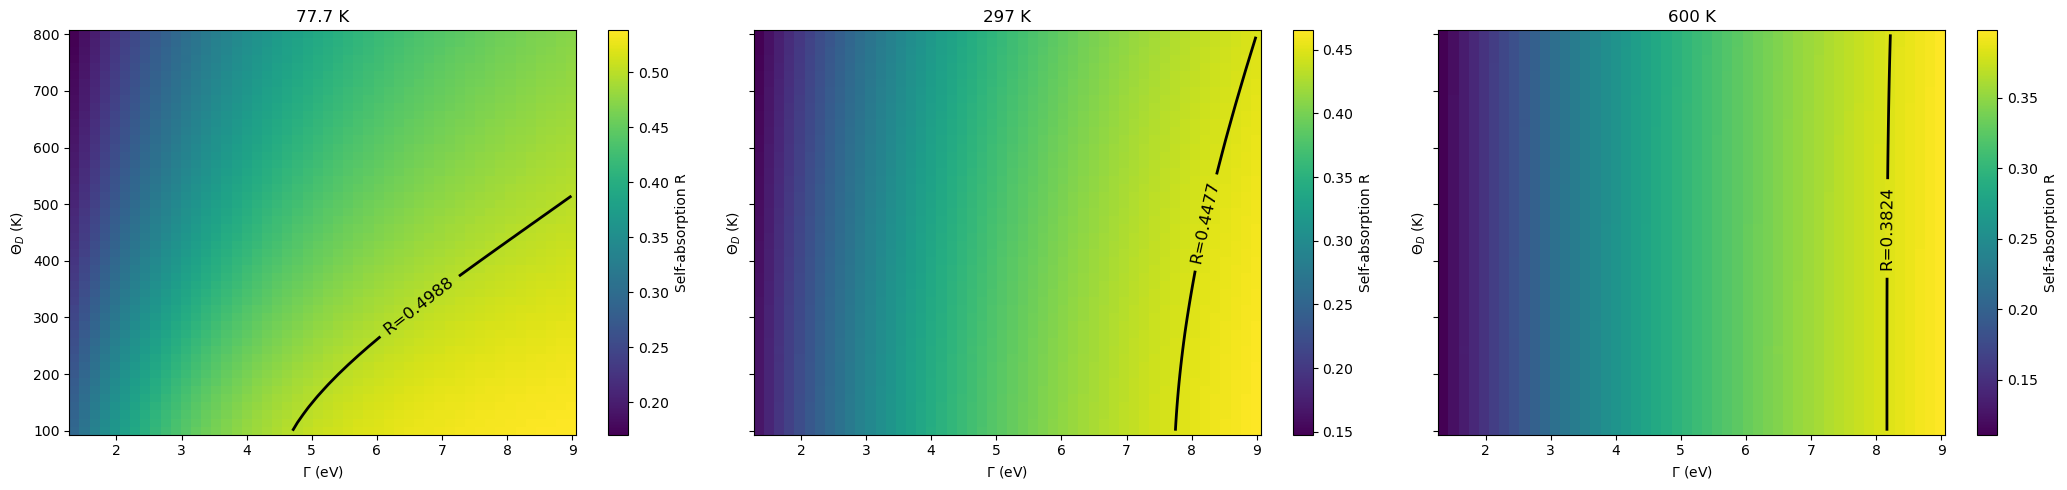

In [27]:
fig, axes = plt.subplots(1, len(Tmeas), figsize=(7 * len(Tmeas), 5), sharey=True)
if len(Tmeas) == 1:
    axes = [axes]

for ax, T_meas_val in zip(axes, Tmeas):
    im = ax.pcolormesh(Gamma_range_eV, theta_D_range, R_grid_TRSA_6Li[T_meas_val], shading="auto", cmap="viridis")
    R_level = R_self_absorption_TRSA_6Li[T_meas_val]
    contour = ax.contour(Gamma_range_eV, theta_D_range, R_grid_TRSA_6Li[T_meas_val], levels=[R_level], colors="black", linewidths=2)
    ax.clabel(contour, fmt=f"R={R_level:.4f}", fontsize=12)

    colorbar = fig.colorbar(im, ax=ax)
    colorbar.set_label("Self-absorption R")
    ax.set_xlabel(r"$\Gamma$ (eV)")
    ax.set_ylabel(r"$\Theta_D$ (K)")
    ax.set_title(f"{T_meas_val} K")
    #ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
from dataclasses import dataclass

import pymc as pm
import pytensor.tensor as pt
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import gaussian_kde


if "highest_density_point" not in globals():
    def highest_density_point(x_samples, y_samples):
        stacked = np.vstack([x_samples, y_samples])
        density = gaussian_kde(stacked)(stacked)
        max_index = np.argmax(density)
        return x_samples[max_index], y_samples[max_index]


@dataclass(frozen=True)
class BilinearInferenceConfig:
    target_gamma_relative_uncertainty: float = 0.02
    draws: int = 2500
    tune: int = 2500
    chains: int = 4
    cores: int = 2
    target_accept: float = 0.95
    random_seed: int = 42


def bilinear_interpolate_regular_grid(gamma_eV_value, theta_D_value, gamma_axis, theta_axis, grid_values):
    gamma_min = float(gamma_axis[0])
    gamma_step = float(gamma_axis[1] - gamma_axis[0])
    theta_min = float(theta_axis[0])
    theta_step = float(theta_axis[1] - theta_axis[0])

    gamma_position = (gamma_eV_value - gamma_min) / gamma_step
    theta_position = (theta_D_value - theta_min) / theta_step

    gamma_index_low = pt.clip(pt.cast(pt.floor(gamma_position), "int32"), 0, len(gamma_axis) - 2)
    theta_index_low = pt.clip(pt.cast(pt.floor(theta_position), "int32"), 0, len(theta_axis) - 2)

    gamma_index_high = gamma_index_low + 1
    theta_index_high = theta_index_low + 1

    gamma_fraction = gamma_position - pt.cast(gamma_index_low, gamma_position.dtype)
    theta_fraction = theta_position - pt.cast(theta_index_low, theta_position.dtype)

    z00 = grid_values[theta_index_low, gamma_index_low]
    z10 = grid_values[theta_index_low, gamma_index_high]
    z01 = grid_values[theta_index_high, gamma_index_low]
    z11 = grid_values[theta_index_high, gamma_index_high]

    return ((1.0 - gamma_fraction) * (1.0 - theta_fraction) * z00 + gamma_fraction * (1.0 - theta_fraction) * z10 + (1.0 - gamma_fraction) * theta_fraction * z01 + gamma_fraction * theta_fraction * z11)


def finite_difference_gradient(interpolator, gamma_eV_value, theta_D_value, gamma_step_eV, theta_step_K, gamma_bounds, theta_bounds):
    gamma_plus = min(gamma_eV_value + gamma_step_eV, gamma_bounds[1])
    gamma_minus = max(gamma_eV_value - gamma_step_eV, gamma_bounds[0])
    theta_plus = min(theta_D_value + theta_step_K, theta_bounds[1])
    theta_minus = max(theta_D_value - theta_step_K, theta_bounds[0])

    dR_dGamma = (float(interpolator((theta_D_value, gamma_plus))) - float(interpolator((theta_D_value, gamma_minus)))) / (gamma_plus - gamma_minus)
    dR_dTheta = (float(interpolator((theta_plus, gamma_eV_value))) - float(interpolator((theta_minus, gamma_eV_value)))) / (theta_plus - theta_minus)
    return dR_dGamma, dR_dTheta


def build_grid_state():
    gamma_axis = np.asarray(Gamma_range_eV, dtype=float)
    theta_axis = np.asarray(theta_D_range, dtype=float)
    return {"gamma_axis_eV": gamma_axis, "theta_axis_K": theta_axis, "gamma_min_eV": float(gamma_axis.min()), "gamma_max_eV": float(gamma_axis.max()), "theta_min_K": float(theta_axis.min()), "theta_max_K": float(theta_axis.max()), "gamma_step_eV": float(np.diff(gamma_axis).mean()), "theta_step_K": float(np.diff(theta_axis).mean()),}


def build_interpolators_and_tensors(gamma_axis_eV, theta_axis_K):
    interpolators_local = {
        T_meas_val: RegularGridInterpolator((theta_axis_K, gamma_axis_eV), np.asarray(R_grid_TRSA_6Li[T_meas_val], dtype=float), bounds_error=False, fill_value=None) for T_meas_val in Tmeas}
    grid_tensors_local = {T_meas_val: pt.as_tensor_variable(np.asarray(R_grid_TRSA_6Li[T_meas_val], dtype=float)) for T_meas_val in Tmeas}
    return interpolators_local, grid_tensors_local


def resolve_reference_point(grid_state):
    if "trace_nuts" in globals():
        gamma_reference = float(np.mean(trace_nuts.posterior["Gamma_eV"].values))
        theta_reference = float(np.mean(trace_nuts.posterior["theta_D"].values))
        source_label = "trace_nuts posterior mean"
    else:
        gamma_reference = float(GSDecayWidth_6Li.n)
        theta_reference = float(Debye_temperature)
        source_label = "literature Gamma and Debye temperature"

    gamma_reference = float(np.clip(gamma_reference, grid_state["gamma_min_eV"], grid_state["gamma_max_eV"]))
    theta_reference = float(np.clip(theta_reference, grid_state["theta_min_K"], grid_state["theta_max_K"]))
    return gamma_reference, theta_reference, source_label


def resolve_nominal_r_values(interpolators_local, gamma_reference, theta_reference):
    if "R_observed_dict" in globals():
        return {T_meas_val: float(R_observed_dict[T_meas_val].n) for T_meas_val in Tmeas}

    return {T_meas_val: float(R_self_absorption_TRSA_6Li.get(T_meas_val, interpolators_local[T_meas_val]((theta_reference, gamma_reference)))) for T_meas_val in Tmeas}


def compute_required_r_dictionary(config, grid_state, interpolators_local, nominal_r_values, gamma_reference, theta_reference):
    jacobian_rows = []
    count_variance_factors = []

    gamma_bounds = (grid_state["gamma_min_eV"], grid_state["gamma_max_eV"])
    theta_bounds = (grid_state["theta_min_K"], grid_state["theta_max_K"])

    for T_meas_val in Tmeas:
        dR_dGamma, dR_dTheta = finite_difference_gradient(interpolators_local[T_meas_val], gamma_reference, theta_reference, grid_state["gamma_step_eV"], grid_state["theta_step_K"], gamma_bounds, theta_bounds)
        jacobian_rows.append([dR_dGamma, dR_dTheta])

        nominal_r = nominal_r_values[T_meas_val]
        count_variance_factors.append(max((1.0 - nominal_r) * (2.0 - nominal_r), 1e-12))

    jacobian = np.asarray(jacobian_rows, dtype=float)
    count_variance_factors = np.asarray(count_variance_factors, dtype=float)
    weighted_information = jacobian.T @ np.diag(1.0 / count_variance_factors) @ jacobian
    covariance_per_count = np.linalg.pinv(weighted_information)
    required_no_absorber_counts = float(covariance_per_count[0, 0] / (config.target_gamma_relative_uncertainty**2 * gamma_reference**2))

    required_r_uncertainty = {T_meas_val: float(np.sqrt(count_variance_factors[index] / required_no_absorber_counts)) for index, T_meas_val in enumerate(Tmeas)}
    required_r_ufloats = {T_meas_val: ufloat(nominal_r_values[T_meas_val], required_r_uncertainty[T_meas_val]) for T_meas_val in Tmeas}

    return {"jacobian": jacobian, "count_variance_factors": count_variance_factors, "weighted_information_per_no_absorber_count": weighted_information, "covariance_per_single_no_absorber_count": covariance_per_count, "required_no_absorber_counts": required_no_absorber_counts, "required_R_uncertainty_dict": required_r_uncertainty, "required_R_ufloat_dict": required_r_ufloats}


def sample_bilinear_posterior(config, gamma_axis_eV, theta_axis_K, grid_tensors_local, observed_r_dict):
    with pm.Model() as model:
        gamma_eV_parameter = pm.Uniform("Gamma_eV", lower=float(gamma_axis_eV.min()), upper=float(gamma_axis_eV.max()))
        theta_D_parameter = pm.Uniform("theta_D", lower=float(theta_axis_K.min()), upper=float(theta_axis_K.max()))

        for T_meas_val in Tmeas:
            predicted_r = pm.Deterministic(f"R_pred_{str(T_meas_val).replace('.', '_')}K_bilinear", bilinear_interpolate_regular_grid( gamma_eV_parameter, theta_D_parameter, gamma_axis_eV, theta_axis_K, grid_tensors_local[T_meas_val]),)
            pm.Normal(f"R_obs_{str(T_meas_val).replace('.', '_')}K_bilinear", mu=predicted_r, sigma=observed_r_dict[T_meas_val].s, observed=observed_r_dict[T_meas_val].n)

        trace = pm.sample(draws=config.draws, tune=config.tune, chains=config.chains, cores=config.cores, target_accept=config.target_accept, random_seed=config.random_seed)

    posterior_gamma = trace.posterior["Gamma_eV"].values.flatten()
    posterior_theta = trace.posterior["theta_D"].values.flatten()
    mode_gamma, mode_theta = highest_density_point(posterior_gamma, posterior_theta)

    return {"model": model, "trace": trace, "posterior_gamma": posterior_gamma, "posterior_theta": posterior_theta, "mode_gamma": mode_gamma, "mode_theta": mode_theta}


def run_bilinear_required_r_analysis(config):
    grid_state = build_grid_state()
    interpolators_local, grid_tensors_local = build_interpolators_and_tensors(grid_state["gamma_axis_eV"], grid_state["theta_axis_K"],)
    gamma_reference, theta_reference, reference_source = resolve_reference_point(grid_state)
    nominal_r_values = resolve_nominal_r_values(interpolators_local, gamma_reference, theta_reference)
    required_r_results = compute_required_r_dictionary(config, grid_state, interpolators_local, nominal_r_values, gamma_reference, theta_reference,)
    posterior_results = sample_bilinear_posterior(config, grid_state["gamma_axis_eV"], grid_state["theta_axis_K"], grid_tensors_local, required_r_results["required_R_ufloat_dict"])

    return {**grid_state, **required_r_results, **posterior_results, "grid_tensors": grid_tensors_local, "interpolators": interpolators_local, "reference_gamma_eV": gamma_reference, "reference_theta_D": theta_reference, "reference_source": reference_source, "nominal_R_values": nominal_r_values,}

In [29]:
bilinear_config = BilinearInferenceConfig(
    target_gamma_relative_uncertainty=0.005,  # change this value and rerun the cell
    draws=2500,
    tune=2500,
    chains=4,
    cores=2,
    target_accept=0.95,
    random_seed=42,
)

bilinear_results = run_bilinear_required_r_analysis(bilinear_config)

target_gamma_relative_uncertainty = bilinear_config.target_gamma_relative_uncertainty
required_R_ufloat_dict = bilinear_results["required_R_ufloat_dict"]

print(f"Reference point source: {bilinear_results['reference_source']}")
print(f"target_gamma_relative_uncertainty = {target_gamma_relative_uncertainty:.6f}")
print("Required R values by temperature:")
print(bilinear_results["required_R_ufloat_dict"])
print(f"Gamma = {bilinear_results['mode_gamma']:.4f} eV")
print(f"theta_D = {bilinear_results['mode_theta']:.2f} K")

Initializing NUTS using jitter+adapt_diag...
/home/kprifti/miniconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [Gamma_eV, theta_D]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 6 seconds.


Reference point source: literature Gamma and Debye temperature
target_gamma_relative_uncertainty = 0.005000
Required R values by temperature:
{77.7: 0.4988069450103749+/-0.000857362573699391, 297: 0.4477285497367828+/-0.0009151743877166606, 600: 0.38236311839620585+/-0.0009879861506753638}
Gamma = 8.1745 eV
theta_D = 448.93 K


In [30]:
gamma_axis_eV = bilinear_results["gamma_axis_eV"]
theta_axis_K = bilinear_results["theta_axis_K"]
gamma_min_eV = bilinear_results["gamma_min_eV"]
gamma_max_eV = bilinear_results["gamma_max_eV"]
theta_min_K = bilinear_results["theta_min_K"]
theta_max_K = bilinear_results["theta_max_K"]
gamma_step_eV = bilinear_results["gamma_step_eV"]
theta_step_K = bilinear_results["theta_step_K"]
grid_tensors = bilinear_results["grid_tensors"]
interpolators = bilinear_results["interpolators"]
reference_gamma_eV = bilinear_results["reference_gamma_eV"]
reference_theta_D = bilinear_results["reference_theta_D"]
nominal_R_values = bilinear_results["nominal_R_values"]
jacobian = bilinear_results["jacobian"]
count_variance_factors = bilinear_results["count_variance_factors"]
weighted_information_per_no_absorber_count = bilinear_results["weighted_information_per_no_absorber_count"]
covariance_per_single_no_absorber_count = bilinear_results["covariance_per_single_no_absorber_count"]
required_no_absorber_counts = bilinear_results["required_no_absorber_counts"]
required_R_uncertainty_dict = bilinear_results["required_R_uncertainty_dict"]
required_R_ufloat_dict = bilinear_results["required_R_ufloat_dict"]
R_observed_bilinear_dict = required_R_ufloat_dict
bilinear_self_absorption_model = bilinear_results["model"]
bilinear_trace_nuts = bilinear_results["trace"]
posterior_gamma_bilinear = bilinear_results["posterior_gamma"]
posterior_theta_bilinear = bilinear_results["posterior_theta"]
mode_gamma_bilinear = bilinear_results["mode_gamma"]
mode_theta_bilinear = bilinear_results["mode_theta"]

array([[<Axes: title={'center': 'Gamma_eV'}>,
        <Axes: title={'center': 'Gamma_eV'}>],
       [<Axes: title={'center': 'theta_D'}>,
        <Axes: title={'center': 'theta_D'}>]], dtype=object)

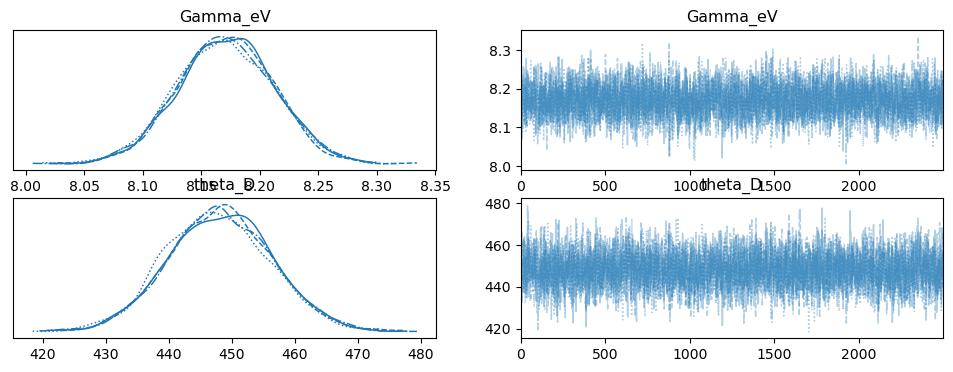

In [31]:
az.plot_trace(bilinear_trace_nuts, var_names=["Gamma_eV", "theta_D"])


In [32]:
az.summary(bilinear_trace_nuts, var_names=["Gamma_eV", "theta_D"], hdi_prob=0.681)

,mean,sd,hdi_15.95%,hdi_84.05%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gamma_eV,8.171,0.041,8.134,8.216,0.001,0.000,4180.0,5118.0,1.0
theta_D,448.103,8.219,440.047,456.336,0.135,0.092,3704.0,4543.0,1.0


## Heatmap plots

In [ ]:
def build_bilinear_posterior_summary(results, hdi_prob=0.681, grid_size=300):
    gamma_samples = np.asarray(results["posterior_gamma"], dtype=float)
    theta_samples = np.asarray(results["posterior_theta"], dtype=float)
    gamma_axis = np.asarray(results["gamma_axis_eV"], dtype=float)
    theta_axis = np.asarray(results["theta_axis_K"], dtype=float)

    mean_gamma = float(np.mean(gamma_samples))
    mean_theta = float(np.mean(theta_samples))
    gamma_hdi = az.hdi(gamma_samples, hdi_prob=hdi_prob)
    theta_hdi = az.hdi(theta_samples, hdi_prob=hdi_prob)

    gamma_xerr = np.array([[mean_gamma - gamma_hdi[0]], [gamma_hdi[1] - mean_gamma]])
    theta_yerr = np.array([[mean_theta - theta_hdi[0]], [theta_hdi[1] - mean_theta]])

    gamma_errorbar = ufloat(mean_gamma, 0.5 * float(gamma_xerr.sum()))
    theta_errorbar = ufloat(mean_theta, 0.5 * float(theta_yerr.sum()))

    posterior_kde = gaussian_kde(np.vstack([gamma_samples, theta_samples]))
    fine_gamma = np.linspace(gamma_axis.min(), gamma_axis.max(), grid_size)
    fine_theta = np.linspace(theta_axis.min(), theta_axis.max(), grid_size)
    fine_gamma_mesh, fine_theta_mesh = np.meshgrid(fine_gamma, fine_theta)
    posterior_density = posterior_kde(np.vstack([fine_gamma_mesh.ravel(), fine_theta_mesh.ravel()])).reshape(fine_gamma_mesh.shape)
    posterior_density /= posterior_density.max()

    gamma_padding = max(0.15, 2.0 * float(gamma_xerr.max()), 4.0 * np.std(gamma_samples, ddof=1))
    theta_padding = max(15.0, 2.0 * float(theta_yerr.max()), 4.0 * np.std(theta_samples, ddof=1))
    density_levels = np.quantile(posterior_density, [0.68, 0.9, 0.97])

    return {"mean_gamma": mean_gamma, "mean_theta": mean_theta, "gamma_hdi": gamma_hdi, "theta_hdi": theta_hdi, "gamma_xerr": gamma_xerr, "theta_yerr": theta_yerr, "gamma_errorbar": gamma_errorbar, "theta_errorbar": theta_errorbar, "posterior_kde": posterior_kde, "fine_gamma": fine_gamma, "fine_theta": fine_theta, "fine_gamma_mesh": fine_gamma_mesh, "fine_theta_mesh": fine_theta_mesh, "posterior_density": posterior_density, "gamma_padding": gamma_padding, "theta_padding": theta_padding, "density_levels": density_levels}

Gamma = 8.17+/-0.04
Theta_D = 448+/-8


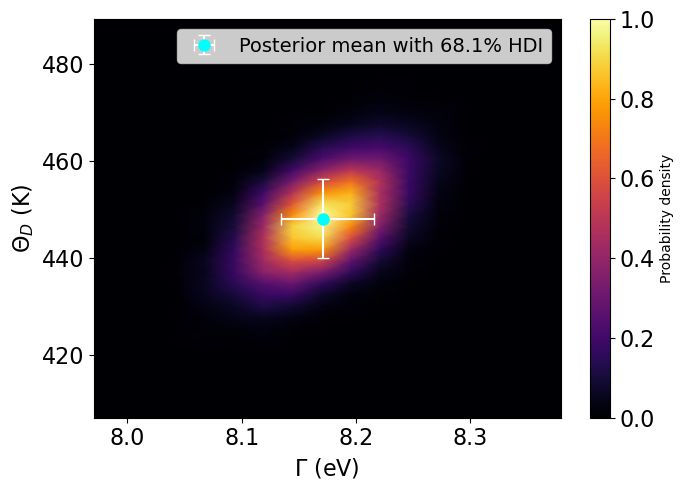

In [81]:
posterior_summary_bilinear = build_bilinear_posterior_summary(bilinear_results, hdi_prob=0.681, grid_size=300)

print(f"Gamma = {posterior_summary_bilinear["gamma_errorbar"]}")
print(f"Theta_D = {posterior_summary_bilinear["theta_errorbar"]}")

plt.figure(figsize=(7, 5))
ax = plt.gca()
im = ax.pcolormesh(posterior_summary_bilinear["fine_gamma"], posterior_summary_bilinear["fine_theta"], posterior_summary_bilinear["posterior_density"], shading="gouraud", cmap="inferno", vmin=0.0, vmax=1.0,)

ax.contour(posterior_summary_bilinear["fine_gamma"], posterior_summary_bilinear["fine_theta"], posterior_summary_bilinear["posterior_density"], levels=np.sort(np.unique(posterior_summary_bilinear["density_levels"])), colors="white", linewidths=1.2, alpha=0.85)
ax.errorbar(posterior_summary_bilinear["mean_gamma"], posterior_summary_bilinear["mean_theta"], xerr=posterior_summary_bilinear["gamma_xerr"], yerr=posterior_summary_bilinear["theta_yerr"], fmt="o", color="cyan", ecolor="white", elinewidth=1.5, capsize=4, markersize=8, label="Posterior mean with 68.1% HDI")
ax.set_xlim(max(gamma_axis_eV.min(), posterior_summary_bilinear["gamma_hdi"][0] - posterior_summary_bilinear["gamma_padding"]), min(gamma_axis_eV.max(), posterior_summary_bilinear["gamma_hdi"][1] + posterior_summary_bilinear["gamma_padding"]),)
ax.set_ylim(max(theta_axis_K.min(), posterior_summary_bilinear["theta_hdi"][0] - posterior_summary_bilinear["theta_padding"]), min(theta_axis_K.max(), posterior_summary_bilinear["theta_hdi"][1] + posterior_summary_bilinear["theta_padding"]),)

colorbar = plt.colorbar(im, ax=ax)
colorbar.set_label("Probability density")
colorbar.ax.tick_params(labelsize=16)
ax.set_xlabel(r"$\Gamma$ (eV)", fontsize=16)
ax.set_ylabel(r"$\Theta_D$ (K)", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
#ax.set_title("Bilinear PyMC posterior heatmap")
ax.legend(loc="best", fontsize=14)
plt.tight_layout()
plt.show()

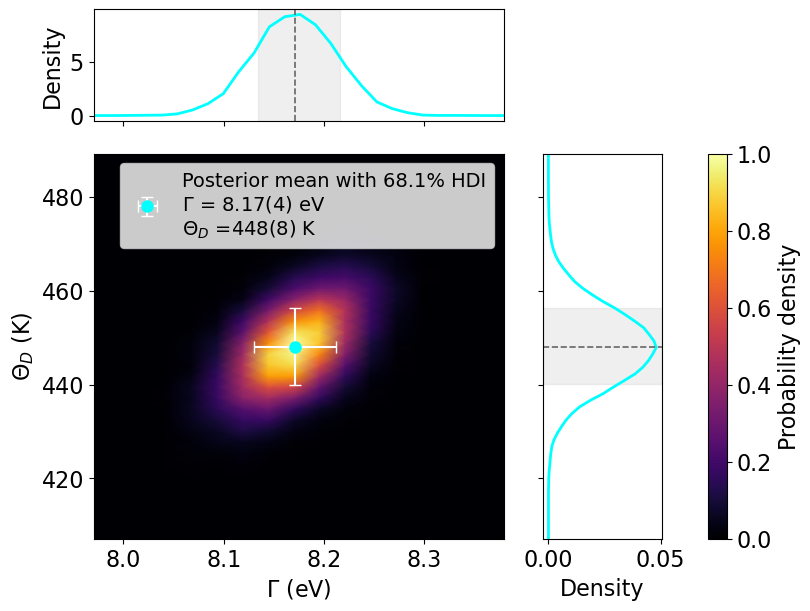

In [75]:
from matplotlib import gridspec

bilinear_gamma_density = gaussian_kde(posterior_gamma_bilinear)
bilinear_theta_density = gaussian_kde(posterior_theta_bilinear)

def format_value_error(nominal_value, sigma_value):
    if sigma_value <= 0:
        return f"{nominal_value:.4g}"
    sigma_exponent = int(np.floor(np.log10(abs(sigma_value))))
    decimal_places = max(0, -sigma_exponent)
    rounded_nominal = round(nominal_value, decimal_places)
    rounded_sigma = round(sigma_value, decimal_places)
    error_digits = int(round(rounded_sigma * (10 ** decimal_places)))
    return f"{rounded_nominal:.{decimal_places}f}({error_digits})"

gamma_legend_value = format_value_error(posterior_summary_bilinear["gamma_errorbar"].n, posterior_summary_bilinear["gamma_errorbar"].s)
theta_legend_value = format_value_error(posterior_summary_bilinear["theta_errorbar"].n, posterior_summary_bilinear["theta_errorbar"].s)

gamma_density_axis = np.linspace(gamma_axis_eV.min(), gamma_axis_eV.max(), 500)
theta_density_axis = np.linspace(theta_axis_K.min(), theta_axis_K.max(), 500)
gamma_density_values = bilinear_gamma_density(gamma_density_axis)
theta_density_values = bilinear_theta_density(theta_density_axis)

fig = plt.figure(figsize=(8, 6), constrained_layout=True)
grid = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[4.5, 1.3], height_ratios=[1.3, 4.5], wspace=0.05, hspace=0.05,)

ax_top = fig.add_subplot(grid[0, 0])
ax_joint = fig.add_subplot(grid[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(grid[1, 1], sharey=ax_joint)

im = ax_joint.pcolormesh(posterior_summary_bilinear["fine_gamma"], posterior_summary_bilinear["fine_theta"], posterior_summary_bilinear["posterior_density"], shading="gouraud", cmap="inferno", vmin=0.0, vmax=1.0)

ax_joint.contour(posterior_summary_bilinear["fine_gamma"], posterior_summary_bilinear["fine_theta"], posterior_summary_bilinear["posterior_density"], levels=np.sort(np.unique(posterior_summary_bilinear["density_levels"])), colors="white", linewidths=1.2, alpha=0.85)

ax_joint.errorbar(posterior_summary_bilinear["mean_gamma"], posterior_summary_bilinear["mean_theta"], xerr=posterior_summary_bilinear["gamma_errorbar"].s, yerr=posterior_summary_bilinear["theta_errorbar"].s, fmt="o", color="cyan", ecolor="white", elinewidth=1.5, capsize=4, markersize=8,
label=("Posterior mean with 68.1% HDI\n" r"$\Gamma$ =" f" {gamma_legend_value} eV\n" r"$\Theta_D$ =" f"{theta_legend_value} K"),)

ax_top.plot(gamma_density_axis, gamma_density_values, color="cyan", linewidth=2)
#ax_top.fill_between(gamma_density_axis, gamma_density_values, color="cyan", alpha=0.22)
ax_top.axvline(posterior_summary_bilinear["mean_gamma"], color="#666666", linestyle="--", linewidth=1.2)
ax_top.axvspan(posterior_summary_bilinear["gamma_hdi"][0], posterior_summary_bilinear["gamma_hdi"][1], color="#999999", alpha=0.15)

ax_right.plot(theta_density_values, theta_density_axis, color="cyan", linewidth=2)
#ax_right.fill_betweenx(theta_density_axis, 0.0, theta_density_values, color="cyan", alpha=0.22)
ax_right.axhline(posterior_summary_bilinear["mean_theta"], color="#666666", linestyle="--", linewidth=1.2)
ax_right.axhspan(posterior_summary_bilinear["theta_hdi"][0], posterior_summary_bilinear["theta_hdi"][1], color="#999999", alpha=0.15)

joint_gamma_min = max(gamma_axis_eV.min(), posterior_summary_bilinear["gamma_hdi"][0] - posterior_summary_bilinear["gamma_padding"])
joint_gamma_max = min(gamma_axis_eV.max(), posterior_summary_bilinear["gamma_hdi"][1] + posterior_summary_bilinear["gamma_padding"])
joint_theta_min = max(theta_axis_K.min(), posterior_summary_bilinear["theta_hdi"][0] - posterior_summary_bilinear["theta_padding"])
joint_theta_max = min(theta_axis_K.max(), posterior_summary_bilinear["theta_hdi"][1] + posterior_summary_bilinear["theta_padding"])

ax_joint.set_xlim(joint_gamma_min, joint_gamma_max)
ax_joint.set_ylim(joint_theta_min, joint_theta_max)
ax_top.set_xlim(joint_gamma_min, joint_gamma_max)
ax_right.set_ylim(joint_theta_min, joint_theta_max)

ax_top.set_ylabel("Density", fontsize=16)
ax_right.set_xlabel("Density", fontsize=16)
ax_joint.set_xlabel(r"$\Gamma$ (eV)", fontsize=16)
ax_joint.set_ylabel(r"$\Theta_D$ (K)", fontsize=16)
ax_joint.tick_params(axis="both", labelsize=16)
#ax_joint.set_title("Bilinear PyMC posterior with marginal densities")

ax_top.tick_params(axis="both", labelbottom=False, labelsize=16)
ax_right.tick_params(axis="both", labelleft=False, labelsize=16)
ax_top.set_facecolor("white")
#ax_joint.set_facecolor("#111111")
ax_right.set_facecolor("white")

colorbar = fig.colorbar(im, ax=[ax_joint, ax_right], fraction=0.046, pad=0.04)
colorbar.set_label("Probability density", fontsize=16)
colorbar.ax.tick_params(labelsize=16)
ax_joint.legend(loc="best", fontsize=14)
plt.show()

## Estimation of count rates with absorber from counts rates without absorber 

The measured self-absorption is:

$$
R_\mathrm{exp} = 1 - \frac{N_\mathrm{sc}^\mathrm{with}}{N_\mathrm{sc}^\mathrm{without
}}
$$

* the ${A_\mathrm{sc}^\mathrm{without}}$ is estimated using the $N_\mathrm{\gamma}\varepsilon(E_i)$ from TRSA measurement on 27Al
* the $R_\mathrm{exp}$ is calculated using the pymc Bayesian inference approach. This approach estimates what uncertainty the measured self-absorption should have in order to achieve a precision of 0.5% for $\Gamma$ (inverse approach)

For each temperature $T_\mathrm{meas}$, the notebook uses a reference no-absorber measurement time $t_\mathrm{ref}$ (in seconds).
The no-absorber expected counts over that reference time are

$$
N_\mathrm{without} = \dot N_\mathrm{without} \, t_\mathrm{ref},
\qquad
\dot N_\mathrm{without} = \dot N_\mathrm{HPGe2} + \dot N_\mathrm{HPGePol}.
$$

Then, for each Monte Carlo draw, the code samples:

- $N_\mathrm{without}$ from its uncertainty distribution
- $R_\mathrm{exp}(T)$ from the required $R$ distribution at that temperature

Using the self-absorption definition, the with-absorber counts for that draw are

$$
N_\mathrm{with}(T) = N_\mathrm{without}\,\bigl(1 - R_\mathrm{exp}(T)\bigr).
$$

So the with-absorber count rate is

$$
\dot N_\mathrm{with}(T) = \frac{N_\mathrm{with}(T)}{t_\mathrm{ref}}
= \dot N_\mathrm{without}\,\bigl(1 - R_\mathrm{exp}(T)\bigr).
$$

Finally, the required measurement time with absorber to recover the same no-absorber statistics is

$$
t_\mathrm{with}(T) = \frac{N_\mathrm{without}}{\dot N_\mathrm{with}(T)}
= \frac{t_\mathrm{ref}}{1 - R_\mathrm{exp}(T)}.
$$

This last relation shows an important point: $N_\mathrm{without}$ cancels analytically, so the uncertainty in $t_\mathrm{with}$ is driven mainly by the uncertainty in $R_\mathrm{exp}(T)$.

In [107]:
duration_days = 25  # measurement duration without absorber
duration_NRF_li6 = duration_days * 24 * 3600 # in seconds
ref_duration_s = duration_NRF_li6  # current reference duration in seconds
reference_duration_days = ref_duration_s / 3600 / 24
current_total_expected_peak_counts = (expected_peak_counts_HPGe2 + expected_peak_counts_HPGePol) * ref_duration_s # the total counts in this case i for two HPGe detectors, the expected counts are obtained using the "known" N_gamma*elpsilon value from the TRRA measurement on 27Al

chain_count = 4
draws_per_chain = 10000
hdi_prob = 0.681
sample_shape = (chain_count, draws_per_chain)
rng = np.random.default_rng(123)

def draw_truncated_normal(mu, sigma, lower, upper, size, random_generator):
    if sigma <= 0:
        return np.full(size, mu, dtype=float)
    a = (lower - mu) / sigma
    b = (upper - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)

In [124]:
# Counts for the measurement wihtout absorber (classical NRF)
N_without_absorber_samples = draw_truncated_normal(current_total_expected_peak_counts.n, current_total_expected_peak_counts.s, lower=0.0, upper=np.inf, size=sample_shape, random_generator=rng)
rate_without_absorber_samples = N_without_absorber_samples / ref_duration_s

duration_results_by_temperature = {}
for temperature_value, required_R_value in required_R_ufloat_dict.items():
    Rexp_samples = draw_truncated_normal(required_R_value.n, required_R_value.s, lower=0.0, upper=1.0, size=sample_shape, random_generator=rng)

    attenuation_factor_samples = 1.0 - Rexp_samples
    N_with_absorber_samples = N_without_absorber_samples * attenuation_factor_samples
    rate_with_absorber_samples = N_with_absorber_samples / ref_duration_s
    duration_for_equal_statistics_s = N_without_absorber_samples / rate_with_absorber_samples
    duration_for_equal_statistics_days = duration_for_equal_statistics_s / 3600 / 24

    duration_results_by_temperature[temperature_value] = {"R": required_R_value, "rate_without_absorber_mean": np.mean(rate_without_absorber_samples), "rate_with_absorber_mean": np.mean(rate_with_absorber_samples), "duration_days_samples": duration_for_equal_statistics_days, "duration_days_hdi": az.hdi(duration_for_equal_statistics_days.reshape(-1), hdi_prob=hdi_prob), "duration_days_mean": np.mean(duration_for_equal_statistics_days)}

print(
    f"Measurement time = {reference_duration_days:.2f} d:\n"
    f"Number of counts {current_total_expected_peak_counts.n:.0f} ± {current_total_expected_peak_counts.n**0.5:.0f} expected counts without absorber"
)

Measurement time = 25.00 d:
Number of counts 354568 ± 595 expected counts without absorber


In [125]:
# Counts from the measurement with absorber
duration_without_absorber_days = ref_duration_s / 3600 / 24

duration_results_table = pd.DataFrame(
    [{
            "T_meas (K)": temperature_value,
            "R_exp": duration_results_by_temperature[temperature_value]["R"].n,
            "sigma_R": duration_results_by_temperature[temperature_value]["R"].s,
            "Rate without absorber (counts/s)": duration_results_by_temperature[temperature_value]["rate_without_absorber_mean"],
            "Rate with absorber (counts/s)": duration_results_by_temperature[temperature_value]["rate_with_absorber_mean"],
            "Duration without absorber (days)": duration_without_absorber_days,
            "Mean duration with absorber (days)": duration_results_by_temperature[temperature_value]["duration_days_mean"],
            f"{hdi_prob:.1%} HDI with absorber (days)": (
                f"[{duration_results_by_temperature[temperature_value]['duration_days_hdi'][0]:.4f}, "
                f"{duration_results_by_temperature[temperature_value]['duration_days_hdi'][1]:.4f}]"
            )} for temperature_value in sorted(duration_results_by_temperature)])

duration_results_table["R_exp"] = duration_results_table["R_exp"].map(lambda value: f"{value:.6f}")
duration_results_table["sigma_R"] = duration_results_table["sigma_R"].map(lambda value: f"{value:.6f}")
duration_results_table["Rate without absorber (counts/s)"] = duration_results_table["Rate without absorber (counts/s)"].map(lambda value: f"{value:.4f}")
duration_results_table["Rate with absorber (counts/s)"] = duration_results_table["Rate with absorber (counts/s)"].map(lambda value: f"{value:.4f}")
duration_results_table["Duration without absorber (days)"] = duration_results_table["Duration without absorber (days)"].map(lambda value: f"{value:.4f}")
duration_results_table["Mean duration with absorber (days)"] = duration_results_table["Mean duration with absorber (days)"].map(lambda value: f"{value:.4f}")

display(duration_results_table)

,T_meas (K),R_exp,sigma_R,Rate without absorber (counts/s),Rate with absorber (counts/s),Duration without absorber (days),Mean duration with absorber (days),68.1% HDI with absorber (days)
0,77.7,0.498807,0.000857,0.1642,0.0823,25.0000,49.8806,"[49.7971, 49.9653]"
1,297.0,0.447729,0.000915,0.1642,0.0907,25.0000,45.2677,"[45.1955, 45.3440]"
2,600.0,0.382363,0.000988,0.1642,0.1014,25.0000,40.4771,"[40.4126, 40.5409]"


In [126]:
duration_results_table = pd.DataFrame(
    [{
            "T_meas (K)": temperature_value,
            "R_exp": duration_results_by_temperature[temperature_value]["R"].n,
            "sigma_R": duration_results_by_temperature[temperature_value]["R"].s,
            "Rate without absorber (counts/s)": duration_results_by_temperature[temperature_value]["rate_without_absorber_mean"],
            "Rate with absorber (counts/s)": duration_results_by_temperature[temperature_value]["rate_with_absorber_mean"],
            "Duration without absorber (days)": duration_without_absorber_days,
            "Mean duration with absorber (days)": duration_results_by_temperature[temperature_value]["duration_days_mean"],
            f"{hdi_prob:.1%} HDI with absorber (days)": (
                f"[{duration_results_by_temperature[temperature_value]['duration_days_hdi'][0]:.4f}, "
                f"{duration_results_by_temperature[temperature_value]['duration_days_hdi'][1]:.4f}]")}
        for temperature_value in sorted(duration_results_by_temperature)])

# Calculate peak volumes BEFORE formatting (using original numeric values)
duration_results_table["Peak volume without absorber (counts)"] = (
    duration_results_table["Rate without absorber (counts/s)"] * duration_results_table["Duration without absorber (days)"] * 86400)

duration_results_table["Peak volume with absorber (counts)"] = (
    duration_results_table["Rate with absorber (counts/s)"] * duration_results_table["Mean duration with absorber (days)"] * 86400)


duration_results_table["R_exp"] = duration_results_table["R_exp"].map(lambda value: f"{value:.6f}")
duration_results_table["sigma_R"] = duration_results_table["sigma_R"].map(lambda value: f"{value:.6f}")
duration_results_table["Rate without absorber (counts/s)"] = duration_results_table["Rate without absorber (counts/s)"].map(lambda value: f"{value:.4f}")
duration_results_table["Rate with absorber (counts/s)"] = duration_results_table["Rate with absorber (counts/s)"].map(lambda value: f"{value:.4f}")
duration_results_table["Duration without absorber (days)"] = duration_results_table["Duration without absorber (days)"].map(lambda value: f"{value:.4f}")
duration_results_table["Mean duration with absorber (days)"] = duration_results_table["Mean duration with absorber (days)"].map(lambda value: f"{value:.4f}")
duration_results_table["Peak volume without absorber (counts)"] = duration_results_table["Peak volume without absorber (counts)"].map(lambda value: f"{value:.0f}")
duration_results_table["Peak volume with absorber (counts)"] = duration_results_table["Peak volume with absorber (counts)"].map(lambda value: f"{value:.0f}")

# Convert peak-volume columns back to numeric (they were formatted as strings)
peak_without_numeric = pd.to_numeric(duration_results_table["Peak volume without absorber (counts)"], errors="coerce")
peak_with_numeric = pd.to_numeric(duration_results_table["Peak volume with absorber (counts)"], errors="coerce")

# Poisson uncertainties: sigma = sqrt(N)
duration_results_table["Unc peak volume without absorber (counts)"] = np.sqrt(peak_without_numeric)
duration_results_table["Unc peak volume with absorber (counts)"] = np.sqrt(peak_with_numeric)

# Optional compact ± representation
duration_results_table["Peak without absorber (N ± σ)"] = [f"{n:.0f} ± {s:.1f}" for n, s in zip(peak_without_numeric, duration_results_table["Unc peak volume without absorber (counts)"])]
duration_results_table["Peak with absorber (N ± σ)"] = [f"{n:.0f} ± {s:.1f}" for n, s in zip(peak_with_numeric, duration_results_table["Unc peak volume with absorber (counts)"])]

# Keep uncertainty columns formatted for display
duration_results_table["Unc peak volume without absorber (counts)"] = duration_results_table["Unc peak volume without absorber (counts)"].map(lambda value: f"{value:.1f}")
duration_results_table["Unc peak volume with absorber (counts)"] = duration_results_table["Unc peak volume with absorber (counts)"].map(lambda value: f"{value:.1f}")

display(duration_results_table)

,T_meas (K),R_exp,sigma_R,Rate without absorber (counts/s),Rate with absorber (counts/s),Duration without absorber (days),Mean duration with absorber (days),68.1% HDI with absorber (days),Peak volume without absorber (counts),Peak volume with absorber (counts),Unc peak volume without absorber (counts),Unc peak volume with absorber (counts),Peak without absorber (N ± σ),Peak with absorber (N ± σ)
0,77.7,0.498807,0.000857,0.1642,0.0823,25.0000,49.8806,"[49.7971, 49.9653]",354592,354593,595.5,595.5,354592 ± 595.5,354593 ± 595.5
1,297.0,0.447729,0.000915,0.1642,0.0907,25.0000,45.2677,"[45.1955, 45.3440]",354592,354593,595.5,595.5,354592 ± 595.5,354593 ± 595.5
2,600.0,0.382363,0.000988,0.1642,0.1014,25.0000,40.4771,"[40.4126, 40.5409]",354592,354593,595.5,595.5,354592 ± 595.5,354593 ± 595.5


In [117]:
R_results = []
R_output= {}
for idx, row in duration_results_table.iterrows():
    # Use numeric values, not formatted strings
    peak_without = float(row["Rate without absorber (counts/s)"]) * float(row["Duration without absorber (days)"]) * 86400
    peak_with = float(row["Rate with absorber (counts/s)"]) * float(row["Mean duration with absorber (days)"]) * 86400

    # Create ufloats with Poisson uncertainties
    A_NRF = ufloat(peak_without, np.sqrt(peak_without))
    A_TRSA = ufloat(peak_with, np.sqrt(peak_with))
    
    # Convert durations to seconds
    t_NRF_sec = float(row["Duration without absorber (days)"]) * 86400
    t_TRSA_sec = float(row["Mean duration with absorber (days)"]) * 86400
    
    # Calculate R with uncertainty
    R_calc = 1 - (A_TRSA / t_TRSA_sec) / (A_NRF / t_NRF_sec)
    R_results.append({
        "T_meas (K)": row["T_meas (K)"],
        "A_NRF": A_NRF,
        "A_TRSA": A_TRSA,
        "R_exp": row["R_exp"],
        "R_calculated": R_calc
    })
    R_output[row["T_meas (K)"]] = R_calc

df_R = pd.DataFrame(R_results)

# Display nominal ± uncertainty
for col in ["A_NRF", "A_TRSA", "R_calculated"]:
    df_R[col] = df_R[col].map(lambda x: f"{x.nominal_value:.4f} ± {x.std_dev:.4f}")

display(df_R)

,T_meas (K),A_NRF,A_TRSA,R_exp,R_calculated
0,77.7,354672.0000 ± 595.5434,354686.9800 ± 595.5560,0.498807,0.4988 ± 0.0012
1,297.0,354672.0000 ± 595.5434,354739.4257 ± 595.6001,0.447729,0.4476 ± 0.0013
2,600.0,354672.0000 ± 595.5434,354615.6257 ± 595.4961,0.382363,0.3825 ± 0.0015


In [127]:
setup_duration_rows = [{"Setup": "Without absorber", "Duration (days)": duration_without_absorber_days}]

for temperature_value in sorted(duration_results_by_temperature):
    setup_duration_rows.append({"Setup": f"With absorber at T_meas = {temperature_value} K", "Duration (days)": duration_results_by_temperature[temperature_value]["duration_days_mean"]})

setup_duration_table = pd.DataFrame(setup_duration_rows)
total_duration_all_setups_days = setup_duration_table["Duration (days)"].sum()
total_duration_all_setups_hours = 24.0 * total_duration_all_setups_days

setup_duration_table["Duration (days)"] = setup_duration_table["Duration (days)"].map(lambda value: f"{value:.4f}")

display(setup_duration_table)
print(f"Total duration from all setups: {total_duration_all_setups_days:.4f} days ({total_duration_all_setups_hours:.2f} h)")

,Setup,Duration (days)
0,Without absorber,25.0000
1,With absorber at T_meas = 77.7 K,49.8806
2,With absorber at T_meas = 297 K,45.2677
3,With absorber at T_meas = 600 K,40.4771


Total duration from all setups: 160.6254 days (3855.01 h)


## Plot peaks with and without absorber

In [131]:
from scipy.optimize import curve_fit

excitation_energy_keV = 1e3 * li6.excited_states["0^+_1"].excitation_energy
assumed_fwhm_keV = 3.3
peak_sigma_keV = assumed_fwhm_keV / (2.0 * np.sqrt(2.0 * np.log(2.0)))
plot_duration_days = ref_duration_s / 3600 / 24

energy_min_keV = excitation_energy_keV - 4.0 * assumed_fwhm_keV
energy_max_keV = excitation_energy_keV + 4.0 * assumed_fwhm_keV
bin_width_keV = 0.5
histogram_bins = np.arange(energy_min_keV, energy_max_keV + bin_width_keV, bin_width_keV)
fit_energy_axis = np.linspace(energy_min_keV, energy_max_keV, 1200)


def gaussian_counts_per_bin(energy_keV, amplitude, centroid_keV, sigma_keV):
    return amplitude * np.exp(-0.5 * ((energy_keV - centroid_keV) / sigma_keV) ** 2)


def fit_histogram_peak(event_energies):
    counts, edges = np.histogram(event_energies, bins=histogram_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    count_uncertainties = np.sqrt(np.clip(counts.astype(float), 1.0, None))
    parameters, covariance = curve_fit(gaussian_counts_per_bin, centers, counts, sigma=count_uncertainties, absolute_sigma=True, p0=[counts.max(), excitation_energy_keV, peak_sigma_keV], bounds=([0.0, energy_min_keV, 0.1], [np.inf, energy_max_keV, 10.0]))

    amplitude, centroid_keV, sigma_keV_fit = parameters
    sigma_keV_fit_uncertainty = np.sqrt(max(covariance[2, 2], 0.0))
    centroid_keV_uncertainty = np.sqrt(max(covariance[1, 1], 0.0))

    area_conversion = np.sqrt(2.0 * np.pi) / bin_width_keV
    fitted_area_counts = amplitude * sigma_keV_fit * area_conversion
    derivative_amplitude = sigma_keV_fit * area_conversion
    derivative_sigma = amplitude * area_conversion
    area_variance = (derivative_amplitude**2 * covariance[0, 0] + derivative_sigma**2 * covariance[2, 2] + 2.0 * derivative_amplitude * derivative_sigma * covariance[0, 2])
    fitted_area_uncertainty = np.sqrt(max(area_variance, 0.0))

    fitted_fwhm_keV = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_keV_fit
    fitted_fwhm_uncertainty_keV = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_keV_fit_uncertainty

    return {"counts": counts, "edges": edges, "centers": centers, "parameters": parameters, "covariance": covariance, "fitted_area": ufloat(fitted_area_counts, fitted_area_uncertainty), "centroid": ufloat(centroid_keV, centroid_keV_uncertainty), "sigma_keV": ufloat(sigma_keV_fit, sigma_keV_fit_uncertainty), "fwhm_keV": ufloat(fitted_fwhm_keV, fitted_fwhm_uncertainty_keV)}



,T_meas (K),Scenario,Peak volume from fit (counts),Area uncertainty from fit (counts),Gaussian sigma (keV),FWHM (keV)
0,77.7,Without absorber,354565,595.5,1.411,3.323
1,77.7,With absorber,177696,421.5,1.411,3.323
2,297.0,Without absorber,354565,595.5,1.411,3.323
3,297.0,With absorber,195808,442.5,1.410,3.320
4,600.0,Without absorber,354565,595.5,1.411,3.323
5,600.0,With absorber,218968,467.9,1.405,3.307


,T_meas (K),R from fitted areas,sigma_R from fitted areas,Required sigma_R for 0.5% Gamma,Achieved / required sigma_R,Meets 0.5% Gamma target
0,77.7,0.498835,0.001457,0.000857,1.698997,No
1,297.0,0.447750,0.001555,0.000915,1.699019,No
2,600.0,0.382432,0.001679,0.000988,1.698929,No


Using measurement duration: 25.00 d
Assumed input FWHM for histogram generation: 3.30 keV
The Gaussian sigma is the fitted width in energy. The self-absorption precision must be computed from the ratio R = 1 - N_with / N_without, using the fitted peak-area uncertainties.


/tmp/ipykernel_1714622/3190156816.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0.0, 10.10, 1.0, 0.9])


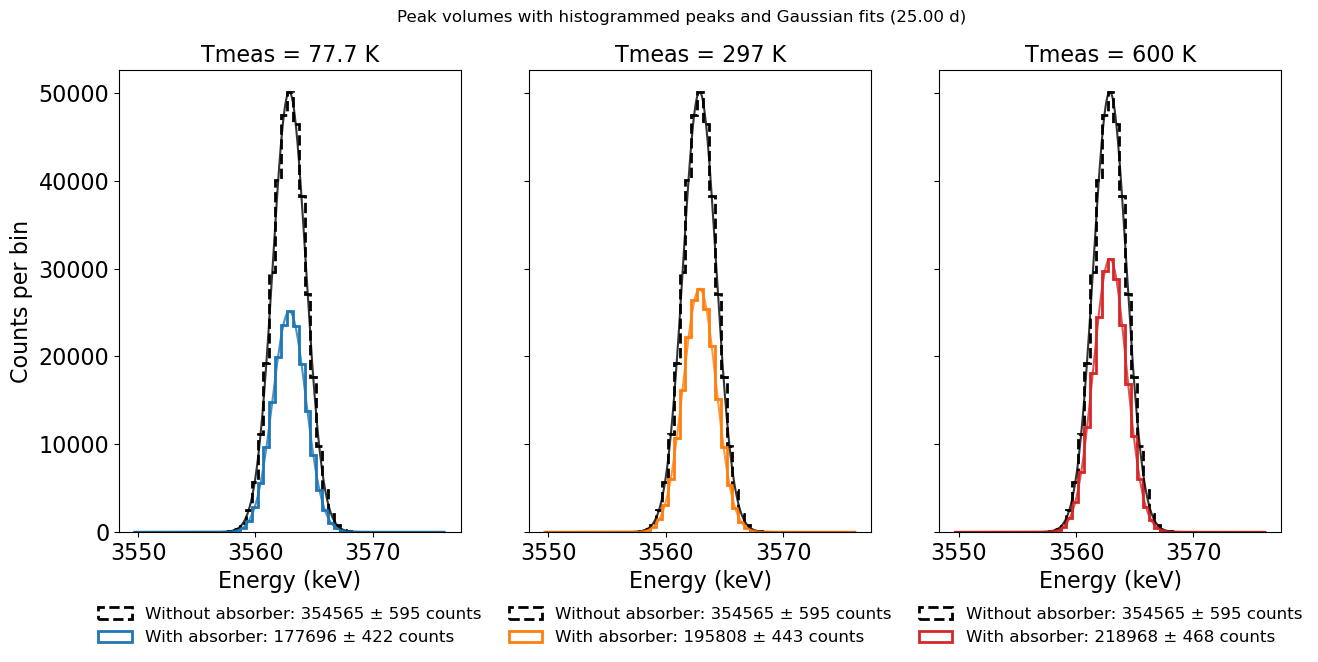

In [195]:
nominal_no_absorber_counts = float(np.median(N_without_absorber_samples.reshape(-1)))
rng_without = np.random.default_rng(2000)
without_event_energies = rng_without.normal(
    loc=excitation_energy_keV,
    scale=peak_sigma_keV,
    size=int(round(nominal_no_absorber_counts)),
)
without_fit_result = fit_histogram_peak(without_event_energies)

peak_volume_summary = {"without_absorber": without_fit_result["fitted_area"], "with_absorber": {}}
peak_shape_summary = {"without_absorber": without_fit_result, "with_absorber": {}}

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
colors = {"without": "black", 77.7: "tab:blue", 297.0: "tab:orange", 600.0: "tab:red"}
summary_rows = []
self_absorption_rows = []

for ax, temperature_value in zip(axes, sorted(required_R_ufloat_dict)):
    nominal_with_absorber_counts = float(np.median(N_without_absorber_samples * (1.0 - required_R_ufloat_dict[temperature_value].n)))
    rng_with = np.random.default_rng(3000 + int(round(10.0 * temperature_value)))
    with_event_energies = rng_with.normal(loc=excitation_energy_keV, scale=peak_sigma_keV, size=int(round(nominal_with_absorber_counts)))
    with_fit_result = fit_histogram_peak(with_event_energies)

    peak_volume_summary["with_absorber"][temperature_value] = with_fit_result["fitted_area"]
    peak_shape_summary["with_absorber"][temperature_value] = with_fit_result

    fitted_R = 1.0 - with_fit_result["fitted_area"] / without_fit_result["fitted_area"]
    target_sigma_R = required_R_uncertainty_dict[temperature_value]
    sigma_ratio = fitted_R.s / target_sigma_R if target_sigma_R > 0 else np.nan

    summary_rows.append({"T_meas (K)": temperature_value, "Scenario": "Without absorber", "Peak volume from fit (counts)": without_fit_result["fitted_area"].n, "Area uncertainty from fit (counts)": without_fit_result["fitted_area"].s, "Gaussian sigma (keV)": without_fit_result["sigma_keV"].n, "FWHM (keV)": without_fit_result["fwhm_keV"].n})
    summary_rows.append({"T_meas (K)": temperature_value, "Scenario": "With absorber", "Peak volume from fit (counts)": with_fit_result["fitted_area"].n, "Area uncertainty from fit (counts)": with_fit_result["fitted_area"].s, "Gaussian sigma (keV)": with_fit_result["sigma_keV"].n, "FWHM (keV)": with_fit_result["fwhm_keV"].n})
    self_absorption_rows.append({"T_meas (K)": temperature_value, "R from fitted areas": fitted_R.n, "sigma_R from fitted areas": fitted_R.s, "Required sigma_R for 0.5% Gamma": target_sigma_R, "Achieved / required sigma_R": sigma_ratio, "Meets 0.5% Gamma target": "Yes" if fitted_R.s <= target_sigma_R else "No"})

    ax.hist(without_event_energies, bins=histogram_bins, histtype="step", linewidth=2, linestyle="--", color=colors["without"], label=( f"Without absorber: {without_fit_result['fitted_area'].n:.0f} " f"± {without_fit_result['fitted_area'].s:.0f} counts"))
    ax.hist(with_event_energies, bins=histogram_bins, histtype="step", linewidth=2, color=colors[temperature_value], label=( f"With absorber: {with_fit_result['fitted_area'].n:.0f} " f"± {with_fit_result['fitted_area'].s:.0f} counts" ))
    ax.plot( fit_energy_axis, gaussian_counts_per_bin(fit_energy_axis, *without_fit_result["parameters"]), color=colors["without"], linewidth=1.5, alpha=0.8, #label=f"Gaussian fit without absorber: sigma = {without_fit_result['sigma_keV'].n:.2f} keV",
    )
    ax.plot(fit_energy_axis, gaussian_counts_per_bin(fit_energy_axis, *with_fit_result["parameters"]), color=colors[temperature_value], linewidth=1.5, alpha=0.8, #label=f"Gaussian fit with absorber: sigma = {with_fit_result['sigma_keV'].n:.2f} keV",
    )

    ax.set_title(f"Tmeas = {temperature_value} K", fontsize=16)
    ax.set_xlabel("Energy (keV)", fontsize=16)
    ax.tick_params(axis="both", labelsize=16)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=12, ncol=1, frameon=False)

peak_volume_table = pd.DataFrame(summary_rows)
peak_volume_table["Peak volume from fit (counts)"] = peak_volume_table["Peak volume from fit (counts)"].map(lambda value: f"{value:.0f}")
peak_volume_table["Area uncertainty from fit (counts)"] = peak_volume_table["Area uncertainty from fit (counts)"].map(lambda value: f"{value:.1f}")
peak_volume_table["Gaussian sigma (keV)"] = peak_volume_table["Gaussian sigma (keV)"].map(lambda value: f"{value:.3f}")
peak_volume_table["FWHM (keV)"] = peak_volume_table["FWHM (keV)"].map(lambda value: f"{value:.3f}")

display(peak_volume_table)

self_absorption_from_fit_table = pd.DataFrame(self_absorption_rows)
self_absorption_from_fit_table["R from fitted areas"] = self_absorption_from_fit_table["R from fitted areas"].map(lambda value: f"{value:.6f}")
self_absorption_from_fit_table["sigma_R from fitted areas"] = self_absorption_from_fit_table["sigma_R from fitted areas"].map(lambda value: f"{value:.6f}")
self_absorption_from_fit_table["Required sigma_R for 0.5% Gamma"] = self_absorption_from_fit_table["Required sigma_R for 0.5% Gamma"].map(lambda value: f"{value:.6f}")
#self_absorption_from_fit_table["Achieved / required sigma_R"] = self_absorption_from_fit_table["Achieved / required sigma_R"].map(lambda value: f"{value:.2f}")
display(self_absorption_from_fit_table)

print(f"Using measurement duration: {plot_duration_days:.2f} d")
print(f"Assumed input FWHM for histogram generation: {assumed_fwhm_keV:.2f} keV")
print("The Gaussian sigma is the fitted width in energy. The self-absorption precision must be computed from the ratio R = 1 - N_with / N_without, using the fitted peak-area uncertainties.")

axes[0].set_ylabel("Counts per bin", fontsize=16)
fig.suptitle(f"Peak volumes with histogrammed peaks and Gaussian fits ({plot_duration_days:.2f} d)", y=0.98)
plt.tight_layout(rect=[0.0, 10.10, 1.0, 0.9])
plt.show()

In [86]:
#TODO: something is wrong with the uncertainty of the peak volumes. Which means i get wrong estimation for the self absorption and as a results the precision of Gamma. Check that and fix the durations
#TODO: add the 297 K in the calclulations, change the mass of the target to the one that was in the previous experiment,a nd cross check if you will get the same duration for that temeprature (297 K). If that is correct then the duraitons of the other measurements should be correct as well. If not, then there is a problem in the code that calculates the durations and you need to find and fix it.

# Sample $\Gamma$ and $\Theta_D$ using the observed/measured $R_\mathrm{exp}$ 

In [204]:
Rexp_by_temperature = R_output # this is the self_absorption obtained after a certain given time (above)
required_R_ufloat_dict # this is the required self-absorption to achieve 0.5% precision on Gamma

{77.7: 0.4988069450103749+/-0.000857362573699391,
 297: 0.4477285497367828+/-0.0009151743877166606,
 600: 0.38236311839620585+/-0.0009879861506753638}

In [209]:
observed_R_rows = [{"T_meas [K]": temperature_value, "Observed R": Rexp_by_temperature[temperature_value].n, "sigma_R": Rexp_by_temperature[temperature_value].s} for temperature_value in sorted(Rexp_by_temperature)]
display(pd.DataFrame(observed_R_rows))

with pm.Model() as observed_R_bilinear_model:
    gamma_eV_observed = pm.Uniform("Gamma_eV", lower=float(gamma_axis_eV.min()), upper=float(gamma_axis_eV.max()),)
    theta_D_observed = pm.Uniform("theta_D", lower=float(theta_axis_K.min()), upper=float(theta_axis_K.max()))

    for temperature_value in sorted(Rexp_by_temperature):
        predicted_R = pm.Deterministic(f"R_pred_{str(temperature_value).replace('.', '_')}K_observed", bilinear_interpolate_regular_grid(gamma_eV_observed, theta_D_observed, gamma_axis_eV, theta_axis_K, grid_tensors[temperature_value]))
        pm.Normal(f"R_obs_{str(temperature_value).replace('.', '_')}K_observed", mu=predicted_R, sigma=Rexp_by_temperature[temperature_value].s, observed=Rexp_by_temperature[temperature_value].n)

    observed_R_trace_nuts = pm.sample(draws=2500, tune=2500, chains=4, cores=2, target_accept=0.95)

observed_posterior_gamma = observed_R_trace_nuts.posterior["Gamma_eV"].values.flatten()
observed_posterior_theta = observed_R_trace_nuts.posterior["theta_D"].values.flatten()

observed_mean_gamma_eV = np.mean(observed_posterior_gamma)
observed_mean_theta_D = np.mean(observed_posterior_theta)
observed_mode_gamma_eV, observed_mode_theta_D = highest_density_point(observed_posterior_gamma, observed_posterior_theta,)
observed_gamma_hdi = az.hdi(observed_posterior_gamma, hdi_prob=0.681)
observed_theta_hdi = az.hdi(observed_posterior_theta, hdi_prob=0.681)

observed_gamma_xerr = np.array([[observed_mean_gamma_eV - observed_gamma_hdi[0]], [observed_gamma_hdi[1] - observed_mean_gamma_eV],])
observed_theta_yerr = np.array([[observed_mean_theta_D - observed_theta_hdi[0]], [observed_theta_hdi[1] - observed_mean_theta_D],])

observed_gamma_value = ufloat(observed_mean_gamma_eV, 0.5 * float(observed_gamma_xerr.sum()))
observed_theta_value = ufloat(observed_mean_theta_D, 0.5 * float(observed_theta_yerr.sum()))

print(f"Best Gamma from observed R = {observed_gamma_value}")
print(f"Best Theta_D from observed R = {observed_theta_value}")
print(f"Posterior mode: Gamma = {observed_mode_gamma_eV:.4f} eV, Theta_D = {observed_mode_theta_D:.2f} K")

observed_summary = az.summary(observed_R_trace_nuts, var_names=["Gamma_eV", "theta_D"], hdi_prob=0.681)
display(observed_summary)

observed_posterior_kde = gaussian_kde(np.vstack([observed_posterior_gamma, observed_posterior_theta]))
observed_fine_gamma_eV = np.linspace(gamma_axis_eV.min(), gamma_axis_eV.max(), 300)
observed_fine_theta_K = np.linspace(theta_axis_K.min(), theta_axis_K.max(), 300)
observed_fine_gamma_mesh, observed_fine_theta_mesh = np.meshgrid(observed_fine_gamma_eV, observed_fine_theta_K,)
observed_posterior_density = observed_posterior_kde(np.vstack([observed_fine_gamma_mesh.ravel(), observed_fine_theta_mesh.ravel(),])).reshape(observed_fine_gamma_mesh.shape)
observed_posterior_density /= observed_posterior_density.max()

observed_density_levels = np.quantile(observed_posterior_density, [0.68, 0.9, 0.97],)

observed_gamma_padding = max(0.15, 2.0 * float(observed_gamma_xerr.max()), 4.0 * np.std(observed_posterior_gamma, ddof=1)) # why 0.15?
observed_theta_padding = max(15.0, 2.0 * float(observed_theta_yerr.max()), 4.0 * np.std(observed_posterior_theta, ddof=1)) # why 0.15?

,T_meas [K],Observed R,sigma_R
0,77.7,0.498782,0.001190
1,297.0,0.447625,0.001312
2,600.0,0.382460,0.001467


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [Gamma_eV, theta_D]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 6 seconds.


Best Gamma from observed R = 8.17+/-0.06
Best Theta_D from observed R = 449+/-12
Posterior mode: Gamma = 8.1693 eV, Theta_D = 450.44 K


,mean,sd,hdi_15.95%,hdi_84.05%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gamma_eV,8.173,0.060,8.109,8.229,0.001,0.001,4076.0,4592.0,1.0
theta_D,448.689,11.566,436.555,459.831,0.180,0.125,4132.0,4439.0,1.0


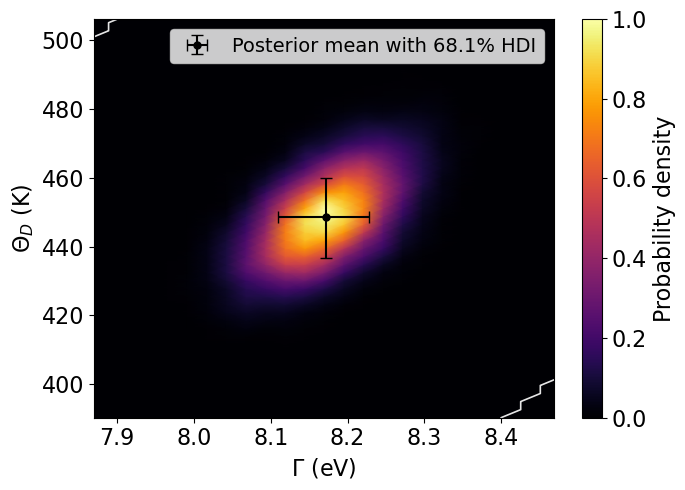

In [225]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(observed_fine_gamma_eV, observed_fine_theta_K, observed_posterior_density, shading="gouraud", cmap="inferno", vmin=0.0, vmax=1.0)
ax.contour(observed_fine_gamma_eV, observed_fine_theta_K, observed_posterior_density, levels=np.sort(np.unique(observed_density_levels)), colors="white", linewidths=1.2, alpha=0.9)
ax.errorbar(observed_mean_gamma_eV, observed_mean_theta_D, xerr=observed_gamma_xerr, yerr=observed_theta_yerr, fmt="o", color="black", ecolor="black", capsize=4, markersize=5, label="Posterior mean with 68.1% HDI")

ax.set_xlim(max(gamma_axis_eV.min(), observed_gamma_hdi[0] - observed_gamma_padding), min(gamma_axis_eV.max(), observed_gamma_hdi[1] + observed_gamma_padding))
ax.set_ylim(max(theta_axis_K.min(), observed_theta_hdi[0] - observed_theta_padding), min(theta_axis_K.max(), observed_theta_hdi[1] + observed_theta_padding))

colorbar = plt.colorbar(im, ax=ax)
colorbar.set_label("Probability density", fontsize=16)
colorbar.ax.tick_params(labelsize=16)
ax.set_xlabel(r"$\Gamma$ (eV)", fontsize=16)
ax.set_ylabel(r"$\Theta_D$ (K)", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
#ax.set_title("Observed-R posterior for Gamma and Theta_D")
ax.legend(loc="best", fontsize=14)
plt.tight_layout()
plt.show()

# Other codes


In [ ]:
def scaled_coordinate(value, lower, upper):
    return 2.0 * (value - lower) / (upper - lower) - 1.0


def polynomial_design_matrix(gamma_scaled, theta_scaled):
    return np.column_stack([np.ones_like(gamma_scaled), gamma_scaled, theta_scaled, gamma_scaled**2, gamma_scaled * theta_scaled, theta_scaled**2, gamma_scaled**3, (gamma_scaled**2) * theta_scaled, gamma_scaled * (theta_scaled**2), theta_scaled**3,])

def fit_surrogate_coefficients(r_grid_values):
    gamma_mesh, theta_mesh = np.meshgrid(Gamma_range_eV, theta_D_range)
    gamma_scaled = scaled_coordinate(gamma_mesh.ravel(), gamma_min_eV, gamma_max_eV)
    theta_scaled = scaled_coordinate(theta_mesh.ravel(), theta_min_K, theta_max_K)
    design = polynomial_design_matrix(gamma_scaled, theta_scaled)
    coefficients, _, _, _ = np.linalg.lstsq(design, r_grid_values.ravel(), rcond=None)
    fitted = design @ coefficients
    rms_error = np.sqrt(np.mean((fitted - r_grid_values.ravel()) ** 2))
    return coefficients, rms_error


def surrogate_response(gamma_eV_value, theta_D_value, coefficients):
    gamma_scaled = scaled_coordinate(gamma_eV_value, gamma_min_eV, gamma_max_eV)
    theta_scaled = scaled_coordinate(theta_D_value, theta_min_K, theta_max_K)
    basis_terms = [pt.ones_like(gamma_scaled), gamma_scaled, theta_scaled, gamma_scaled**2, gamma_scaled * theta_scaled, theta_scaled**2, gamma_scaled**3, (gamma_scaled**2) * theta_scaled, gamma_scaled * (theta_scaled**2), theta_scaled**3,]
    return sum(coefficient * term for coefficient, term in zip(coefficients, basis_terms))


gamma_min_eV = Gamma_range_eV.min()
gamma_max_eV = Gamma_range_eV.max()
theta_min_K = theta_D_range.min()
theta_max_K = theta_D_range.max()

surrogate_coefficients = {}
surrogate_rms = {}
for T_meas_val in Tmeas:
    coefficients, rms_error = fit_surrogate_coefficients(R_grid_TRSA_6Li[T_meas_val])
    surrogate_coefficients[T_meas_val] = coefficients
    surrogate_rms[T_meas_val] = rms_error
    print(f"Surrogate RMS at T = {T_meas_val} K: {rms_error:.3e}")

if "R_observed_dict" not in globals():
    R_observed_dict = {T_meas_val: ufloat(R_self_absorption_TRSA_6Li[T_meas_val], max(5.0 * surrogate_rms[T_meas_val], 1e-3))
        for T_meas_val in Tmeas}
    print("R_observed_dict was not defined; using the TRSA contour values with fallback uncertainties.")

with pm.Model() as self_absorption_model:
    gamma_eV = pm.Uniform("Gamma_eV", lower=gamma_min_eV, upper=gamma_max_eV)
    theta_D = pm.Uniform("theta_D", lower=theta_min_K, upper=theta_max_K)

    for T_meas_val in Tmeas:
        predicted_R = pm.Deterministic(f"R_pred_{str(T_meas_val).replace('.', '_')}K", surrogate_response(gamma_eV, theta_D, surrogate_coefficients[T_meas_val]),)
        observed_R = R_observed_dict[T_meas_val]
        total_sigma = np.sqrt(observed_R.s**2 + surrogate_rms[T_meas_val] ** 2)
        pm.Normal(f"R_obs_{str(T_meas_val).replace('.', '_')}K", mu=predicted_R, sigma=total_sigma, observed=observed_R.n,)

    trace_nuts = pm.sample(draws=2000, tune=2000, chains=4, cores=2, target_accept=0.95, random_seed=42)

posterior_summary = az.summary(trace_nuts, var_names=["Gamma_eV", "theta_D"], hdi_prob=0.681)
print(posterior_summary)

az.plot_trace(trace_nuts, var_names=["Gamma_eV", "theta_D"])
plt.tight_layout()
plt.show()

posterior_gamma = trace_nuts.posterior["Gamma_eV"].values.flatten()
posterior_theta = trace_nuts.posterior["theta_D"].values.flatten()


In [ ]:
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import gaussian_kde

def finite_difference_gradient(interpolator, gamma_eV_value, theta_D_value, gamma_step, theta_step):
    gamma_plus = min(gamma_eV_value + gamma_step, gamma_max_eV)
    gamma_minus = max(gamma_eV_value - gamma_step, gamma_min_eV)
    theta_plus = min(theta_D_value + theta_step, theta_max_K)
    theta_minus = max(theta_D_value - theta_step, theta_min_K)

    dR_dGamma = (float(interpolator((theta_D_value, gamma_plus))) - float(interpolator((theta_D_value, gamma_minus)))) / (gamma_plus - gamma_minus)
    dR_dTheta = (float(interpolator((theta_plus, gamma_eV_value))) - float(interpolator((theta_minus, gamma_eV_value)))) / (theta_plus - theta_minus)
    return dR_dGamma, dR_dTheta


def highest_density_point(x_samples, y_samples):
    stacked = np.vstack([x_samples, y_samples])
    density = gaussian_kde(stacked)(stacked)
    max_index = np.argmax(density)
    return x_samples[max_index], y_samples[max_index]


target_gamma_relative_uncertainty = 0.005
mean_gamma_eV = np.mean(posterior_gamma)
mean_theta_D = np.mean(posterior_theta)
posterior_gamma_sigma = np.std(posterior_gamma, ddof=1)
posterior_theta_sigma = np.std(posterior_theta, ddof=1)
plot_colors = ["blue", "orange", "red"]

gamma_step_eV = float(np.diff(Gamma_range_eV).mean())
theta_step_K = float(np.diff(theta_D_range).mean())

interpolators = {T_meas_val: RegularGridInterpolator((theta_D_range, Gamma_range_eV), R_grid_TRSA_6Li[T_meas_val], bounds_error=False, fill_value=None) for T_meas_val in Tmeas}

jacobian_rows = []
count_variance_factors = []
nominal_R_values = {}
for T_meas_val in Tmeas:
    dR_dGamma, dR_dTheta = finite_difference_gradient(interpolators[T_meas_val], mean_gamma_eV, mean_theta_D, gamma_step_eV, theta_step_K)
    jacobian_rows.append([dR_dGamma, dR_dTheta])

    nominal_R = R_observed_dict[T_meas_val].n if T_meas_val in R_observed_dict else float(interpolators[T_meas_val]((mean_theta_D, mean_gamma_eV)))
    nominal_R_values[T_meas_val] = nominal_R
    count_variance_factors.append((1.0 - nominal_R) * (2.0 - nominal_R))

jacobian = np.array(jacobian_rows, dtype=float)
count_variance_factors = np.array(count_variance_factors, dtype=float)
weighted_information_per_no_absorber_count = jacobian.T @ np.diag(1.0 / count_variance_factors) @ jacobian
covariance_per_single_no_absorber_count = np.linalg.inv(weighted_information_per_no_absorber_count)

required_no_absorber_counts = float(covariance_per_single_no_absorber_count[0, 0] / (target_gamma_relative_uncertainty**2 * mean_gamma_eV**2))
required_R_sigmas = np.sqrt(count_variance_factors / required_no_absorber_counts)
required_R_uncertainty_dict = {T_meas_val: required_R_sigmas[index] for index, T_meas_val in enumerate(Tmeas)}
required_R_ufloat_dict = {T_meas_val: ufloat(nominal_R_values[T_meas_val], required_R_uncertainty_dict[T_meas_val]) for T_meas_val in Tmeas}

for T_meas_val in Tmeas:
    print(f"T = {T_meas_val} K: R = {nominal_R_values[T_meas_val]:.6f} ± {required_R_uncertainty_dict[T_meas_val]:.6f}")

fine_gamma_eV = np.linspace(Gamma_range_eV.min(), Gamma_range_eV.max(), 400)
fine_theta_K = np.linspace(theta_D_range.min(), theta_D_range.max(), 400)
fine_gamma_mesh_eV, fine_theta_mesh_K = np.meshgrid(fine_gamma_eV, fine_theta_K)
fine_points = np.column_stack([fine_theta_mesh_K.ravel(), fine_gamma_mesh_eV.ravel()])

overlap_mask_fine = np.ones(fine_gamma_mesh_eV.shape, dtype=bool)
compatibility_exponent = np.zeros(fine_gamma_mesh_eV.shape, dtype=float)
for T_meas_val in Tmeas:
    interpolated_grid = interpolators[T_meas_val](fine_points).reshape(fine_gamma_mesh_eV.shape)
    normalized_residual = (
        interpolated_grid - nominal_R_values[T_meas_val]
    ) / required_R_uncertainty_dict[T_meas_val]
    overlap_mask_fine &= np.abs(normalized_residual) <= 1.0
    compatibility_exponent += normalized_residual**2

compatibility_score = np.exp(-0.5 * compatibility_exponent)

if overlap_mask_fine.any():
    overlap_gamma_values = fine_gamma_mesh_eV[overlap_mask_fine]
    overlap_theta_values = fine_theta_mesh_K[overlap_mask_fine]
    overlap_weights = compatibility_score[overlap_mask_fine]

    overlap_center_gamma_eV = float(np.average(overlap_gamma_values, weights=overlap_weights))
    overlap_center_theta_D = float(np.average(overlap_theta_values, weights=overlap_weights))

    normalized_distance_to_center = (
        ((fine_gamma_mesh_eV - overlap_center_gamma_eV) / max(posterior_gamma_sigma, gamma_step_eV)) ** 2
        + ((fine_theta_mesh_K - overlap_center_theta_D) / max(posterior_theta_sigma, theta_step_K)) ** 2
    )
    nearest_overlap_distance = np.where(overlap_mask_fine, normalized_distance_to_center, np.inf)
    representative_index = np.unravel_index(np.argmin(nearest_overlap_distance), nearest_overlap_distance.shape)
    representative_gamma_eV = float(fine_gamma_mesh_eV[representative_index])
    representative_theta_D = float(fine_theta_mesh_K[representative_index])

    gamma_xerr = np.array([
        [max(representative_gamma_eV - overlap_gamma_values.min(), 0.0)],
        [max(overlap_gamma_values.max() - representative_gamma_eV, 0.0)],
    ])
    theta_yerr = np.array([
        [max(representative_theta_D - overlap_theta_values.min(), 0.0)],
        [max(overlap_theta_values.max() - representative_theta_D, 0.0)],
    ])
else:
    overlap_gamma_values = np.array([mean_gamma_eV])
    overlap_theta_values = np.array([mean_theta_D])
    representative_index = np.unravel_index(np.argmax(compatibility_score), compatibility_score.shape)
    representative_gamma_eV = float(fine_gamma_mesh_eV[representative_index])
    representative_theta_D = float(fine_theta_mesh_K[representative_index])
    overlap_center_gamma_eV = representative_gamma_eV
    overlap_center_theta_D = representative_theta_D
    gamma_xerr = np.array([[0.0], [0.0]])
    theta_yerr = np.array([[0.0], [0.0]])

gamma_sigma_value = 0.5 * float(gamma_xerr.sum())
theta_sigma_value = 0.5 * float(theta_yerr.sum())
gamma_errorbar_value = ufloat(representative_gamma_eV, gamma_sigma_value)
theta_errorbar_value = ufloat(representative_theta_D, theta_sigma_value)

print(f"Gamma = {gamma_errorbar_value}")
print(f"Theta_D = {theta_errorbar_value}")

gamma_padding = max(0.15, 6.0 * gamma_step_eV, 2.0 * float(gamma_xerr.max()))
theta_padding = max(15.0, 6.0 * theta_step_K, 2.0 * float(theta_yerr.max()))
zoom_gamma_min = max(gamma_min_eV, overlap_gamma_values.min() - gamma_padding)
zoom_gamma_max = min(gamma_max_eV, overlap_gamma_values.max() + gamma_padding)
zoom_theta_min = max(theta_min_K, overlap_theta_values.min() - theta_padding)
zoom_theta_max = min(theta_max_K, overlap_theta_values.max() + theta_padding)

fig, ax = plt.subplots(figsize=(8, 6))
legend_handles = []
for color, T_meas_val in zip(plot_colors, Tmeas):
    R_center = nominal_R_values[T_meas_val]
    sigma_R = required_R_uncertainty_dict[T_meas_val]

    ax.contour(Gamma_range_eV, theta_D_range, R_grid_TRSA_6Li[T_meas_val], levels=[R_center], colors=color, linewidths=2)
    ax.contour( Gamma_range_eV, theta_D_range, R_grid_TRSA_6Li[T_meas_val], levels=[R_center - sigma_R, R_center + sigma_R], colors=color, linewidths=1, linestyles="--", alpha=0.6)
    legend_handles.append( plt.Line2D( [0], [0], color=color, lw=2, label=f"T = {T_meas_val} K: R = {R_center:.4f} ± {sigma_R:.4f}"))

ax.scatter(overlap_center_gamma_eV, overlap_center_theta_D, marker="x", color="black", s=80, linewidths=2)
legend_handles.append(plt.Line2D([0], [0], marker="x", color="black", lw=0, markersize=8, markeredgewidth=2, label="Center of overlap region"))

ax.errorbar(representative_gamma_eV, representative_theta_D, xerr=gamma_xerr, yerr=theta_yerr, fmt="o", color="gold", ecolor="black", elinewidth=1.5, capsize=4, markersize=8)
legend_handles.append(plt.Line2D([0], [0], marker="o", color="gold", markeredgecolor="black", lw=0, markersize=8, label="Representative point inside overlap"))

ax.set_xlabel("Gamma (eV)")
ax.set_ylabel("Theta_D (K)")
ax.set_title("Contour bands from required R uncertainties")
ax.legend(handles=legend_handles, loc="best", fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(fine_gamma_eV, fine_theta_K, compatibility_score, shading="gouraud", cmap="inferno", vmin=0.0, vmax=1.0)

ax.contour(fine_gamma_eV, fine_theta_K, overlap_mask_fine.astype(float), levels=[0.5], colors="white", linewidths=1.5, alpha=0.9)
ax.scatter( overlap_center_gamma_eV, overlap_center_theta_D, marker="x", color="white", s=90, linewidths=2, label="Center of overlap region")
ax.errorbar( representative_gamma_eV, representative_theta_D, xerr=gamma_xerr, yerr=theta_yerr, fmt="o", color="cyan", ecolor="white", elinewidth=1.5, capsize=4, markersize=8, label="Representative point inside overlap")

ax.set_xlim(zoom_gamma_min, zoom_gamma_max)
ax.set_ylim(zoom_theta_min, zoom_theta_max)

colorbar = fig.colorbar(im, ax=ax)
colorbar.set_label("Compatibility score (1 = best agreement)")
ax.set_xlabel("Gamma (eV)")
ax.set_ylabel("Theta_D (K)")
ax.set_title("Zoomed compatibility map and overlap region")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# This code calculates the propagated uncertainty of R_2D based on the uncertainties of the input parameters, using a finite-difference approach to estimate the local sensitivity of R_2D to each parameter. It then combines these contributions in quadrature to get the total uncertainty on R_2D for each T_meas.
def propagated_R_2D_uncertainty(T_meas):
    nominal_parameters = {
        "Gamma": GSDecayWidth_6Li.n * 1e-6,  # Convert from eV to MeV
        "theta_D": Debye_temperature,
        "absorber_mass": li6_absorber_mass.n * g_to_kg,
        "scatterer_mass": li6_scatterer_mass.n * g_to_kg,
        "diameter": target_diameter.n * cm_to_m,
        "enrichment": li6_enrichment.n,
    }

    parameter_specs = {
        "Gamma": (GSDecayWidth_6Li.n * 1e-6, GSDecayWidth_6Li.s * 1e-6, 0.0, None),
        "absorber_mass": (li6_absorber_mass.n * g_to_kg, li6_absorber_mass.s * g_to_kg, 0.0, None),
        "scatterer_mass": (li6_scatterer_mass.n * g_to_kg, li6_scatterer_mass.s * g_to_kg, 0.0, None),
        "diameter": (target_diameter.n * cm_to_m, target_diameter.s * cm_to_m, 0.0, None),
        "enrichment": (li6_enrichment.n, li6_enrichment.s, 0.0, 1.0),
    }

    nominal_value = R_2D(T_meas=T_meas, **nominal_parameters)
    variance = 0.0
    sigma_contributions = {}

    for parameter_name, (mu, sigma, lower_bound, upper_bound) in parameter_specs.items():
        if sigma <= 0:
            sigma_contributions[parameter_name] = 0.0
            continue

        lower_value = max(lower_bound, mu - sigma)
        upper_value = mu + sigma if upper_bound is None else min(upper_bound, mu + sigma)

        if np.isclose(lower_value, upper_value):
            sigma_contributions[parameter_name] = 0.0
            continue

        lower_parameters = nominal_parameters.copy()
        upper_parameters = nominal_parameters.copy()
        lower_parameters[parameter_name] = lower_value
        upper_parameters[parameter_name] = upper_value

        lower_response = R_2D(T_meas=T_meas, **lower_parameters)
        upper_response = R_2D(T_meas=T_meas, **upper_parameters)
        local_derivative = (upper_response - lower_response) / (upper_value - lower_value)
        sigma_contribution = abs(local_derivative) * sigma
        sigma_contributions[parameter_name] = sigma_contribution
        variance += sigma_contribution ** 2

    total_sigma = np.sqrt(variance)
    return nominal_value, total_sigma, sigma_contributions


R_self_absorption_TRSA_6Li = {}
R_self_absorption_uncertainty_TRSA_6Li = {}
for T_meas in Tmeas:
    nominal_value, sigma_value, sigma_contributions = propagated_R_2D_uncertainty(T_meas)
    one_sigma_interval = (
        max(0.0, nominal_value - sigma_value),
        min(1.0, nominal_value + sigma_value),
    )

    R_self_absorption_TRSA_6Li[T_meas] = nominal_value
    R_self_absorption_uncertainty_TRSA_6Li[T_meas] = {
        "sigma": sigma_value,
        "one_sigma_interval": one_sigma_interval,
        "contributions": sigma_contributions,
    }

    print(
        f"Self-absorption at T_meas = {T_meas} K: "
        f"R = {nominal_value:.4f} ± {sigma_value:.4f} "
        f"(1σ, interval [{one_sigma_interval[0]:.4f}, {one_sigma_interval[1]:.4f}])"
    )

In [ ]:
# This code performs a Monte Carlo uncertainty propagation for R_2D by sampling from the input parameter distributions, calculating R_2D for each sample, and then summarizing the resulting distribution of R_2D values to get the mean, standard deviation, and highest density interval (HDI) for each T_meas.
mc_sample_count = 300
mc_hdi_prob = 0.681
mc_rng = np.random.default_rng(2026)


def sample_bounded_normal(mu, sigma, lower, upper, size, random_generator):
    if sigma <= 0:
        return np.full(size, mu, dtype=float)
    a = (lower - mu) / sigma if lower is not None else -np.inf
    b = (upper - mu) / sigma if upper is not None else np.inf
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)


mc_parameter_samples = {
    "Gamma": sample_bounded_normal(GSDecayWidth_6Li.n * 1e-6, GSDecayWidth_6Li.s * 1e-6, 0.0, None, mc_sample_count, mc_rng),
    "absorber_mass": sample_bounded_normal(li6_absorber_mass.n * g_to_kg, li6_absorber_mass.s * g_to_kg, 0.0, None, mc_sample_count, mc_rng),
    "scatterer_mass": sample_bounded_normal(li6_scatterer_mass.n * g_to_kg, li6_scatterer_mass.s * g_to_kg, 0.0, None, mc_sample_count, mc_rng),
    "diameter": sample_bounded_normal(target_diameter.n * cm_to_m, target_diameter.s * cm_to_m, 0.0, None, mc_sample_count, mc_rng),
    "enrichment": sample_bounded_normal(li6_enrichment.n, li6_enrichment.s, 0.0, 1.0, mc_sample_count, mc_rng),
}

R_self_absorption_mc_TRSA_6Li = {}
R_self_absorption_mc_ufloat_TRSA_6Li = {}
mc_rows = []
for T_meas in Tmeas:
    R_samples = np.array([
        R_2D(
            Gamma=mc_parameter_samples["Gamma"][sample_index],
            theta_D=Debye_temperature,
            T_meas=T_meas,
            absorber_mass=mc_parameter_samples["absorber_mass"][sample_index],
            scatterer_mass=mc_parameter_samples["scatterer_mass"][sample_index],
            diameter=mc_parameter_samples["diameter"][sample_index],
            enrichment=mc_parameter_samples["enrichment"][sample_index],
        )
        for sample_index in range(mc_sample_count)
    ])

    mc_interval = az.hdi(R_samples, hdi_prob=mc_hdi_prob)
    R_self_absorption_mc_TRSA_6Li[T_meas] = {
        "samples": R_samples,
        "mean": np.mean(R_samples),
        "median": np.median(R_samples),
        "sigma": np.std(R_samples, ddof=1),
        "hdi": mc_interval,
    }
    R_self_absorption_mc_ufloat_TRSA_6Li[T_meas] = ufloat(
        np.mean(R_samples),
        np.std(R_samples, ddof=1),
    )
    mc_rows.append(
        {
            "T_meas [K]": T_meas,
            "Mean": np.mean(R_samples),
            "Median": np.median(R_samples),
            "Std": np.std(R_samples, ddof=1),
            f"{mc_hdi_prob:.1%} HDI": f"[{mc_interval[0]:.4f}, {mc_interval[1]:.4f}]",
        }
    )

    print(
        f"Monte Carlo self-absorption at T_meas = {T_meas} K: "
        f"R = {np.mean(R_samples):.4f} ± {np.std(R_samples, ddof=1):.4f} "
        f"({mc_hdi_prob:.1%} HDI [{mc_interval[0]:.4f}, {mc_interval[1]:.4f}])"
    )

pd.DataFrame(mc_rows)